In [1]:
# notebook to compare bed files of seqlet calls from:
# MPAC
# PARM
# promoterAI

In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pybedtools
from collections import Counter
import numpy as np
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import matplotlib.ticker as ticker

In [2]:
# open the DF of full 250bp promoters
fullPromoters = pd.read_csv('../processed_data/complete.merged.250bp.promoters.exon.filtered.tsv', sep = '\t')['promoter_id'].tolist()

In [3]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [4]:
# define function for reformatting the uncollapsed mpac seqlet calls:
def mpac_uncollapsed (path2bed,
                      promoterList,
                      motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(('_').join(i.split('_')[:2])) for i in filtered_bed[3]],
                             'attribution' : [float(i.split('_')[-1]) for i in filtered_bed[3]],
                             'gene_id' : filtered_bed['gene_id']})
    bed2plot.loc[:, 'activator_repressor'] = ['Activator' if i > 0 else 'Repressor' for i in bed2plot['attribution']]
    return bed2plot
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed (path2bed,
                    promoterList,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [5]:
# define function for reformatting parm tf calls - uncollapsed
def parmParm_uncollapsed (path2bed,
                          promoterList,
                          motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split(':')[2].split('_')[0] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split(':')[0].split('-')[0].split('_')[0] for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(i.split(':')[0].split('-')[0]) for i in filtered_bed[3]],
                             'attribution' : [float(i.split(':')[1]) for i in filtered_bed[3]],
                             'gene_id' : filtered_bed['gene_id']})
    bed2plot.loc[:, 'activator_repressor'] = ['Activator' if i > 0 else 'Repressor' for i in bed2plot['attribution']]
    return bed2plot
# define function for reformatting parm tf calls - collapsed
def parmParm_collapsed (path2bed,
                        promoterList,
                        motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene_ids
    bed.loc[:, 'gene_id'] = [i.split(':')[2].split('_')[0] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot
# define function for reformatting parm TANGERMEME tf calls - uncollapsed
def parmTangermeme_uncollapsed (path2bed,
                                promoterList,
                                motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotitng purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(('_').join(i.split('_')[:2])) for i in filtered_bed[3]],
                             'attribution' : [float(i.split('_')[-1]) for i in filtered_bed[3]],
                             'gene_id' : filtered_bed['gene_id']})
    bed2plot.loc[:, 'activator_repressor'] = ['Activator' if i > 0 else 'Repressor' for i in bed2plot['attribution']]
    return bed2plot
# define function for reformatting parm TANGERMEME tf calls - collapsed
def parmTangermeme_collapsed (path2bed,
                              promoterList,
                              motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene_ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [6]:
# define function for reformatting the uncollapsed mpac seqlet calls:
def promoterAI_uncollapsed (path2bed,
                      promoterList,
                      motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(('_').join(i.split('_')[:2])) for i in filtered_bed[3]],
                             'attribution' : [float(i.split('_')[-1]) for i in filtered_bed[3]],
                             'gene_id' : filtered_bed['gene_id']})
    bed2plot.loc[:, 'activator_repressor'] = ['Activator' if i > 0 else 'Repressor' for i in bed2plot['attribution']]
    return bed2plot
# define function for reformatting collapsed mpac seqlet calls:
def promoterAI_collapsed (path2bed,
                    promoterList,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [5]:
# define a function for adding necessary columns for plotting comparisons
# we need to consider:
#   the seqlet identification method
#   the seqlet collpsing method
def reformat_seqlets (collapsed,
                      seqlet_method,
                      listOfPromoters,
                      path2bed,
                      motifDict,
                      model):
    ### MPAC ###
    # mpac uncollapsed
    if collapsed == False and model.upper() == 'MPAC':
        return mpac_uncollapsed(path2bed, listOfPromoters, motifDict)
    # mpac collapsed
    if collapsed == True and model.upper() == 'MPAC':
        return mpac_collapsed(path2bed, listOfPromoters, motifDict)
    ### PARM ###
    # parm, parm, uncollapsed
    if collapsed == False and model.upper() == 'PARM' and seqlet_method.upper() == 'PARM':
        return parmParm_uncollapsed(path2bed, listOfPromoters, motifDict)
    # parm, parm, collapsed
    if collapsed == True and model.upper() == 'PARM' and seqlet_method.upper() == 'PARM':
        return parmParm_collapsed(path2bed, listOfPromoters, motifDict)
    # parm, tangermeme, uncollapsed
    if collapsed == False and model.upper() == 'PARM' and seqlet_method.upper() == 'TANGERMEME':
        return parmTangermeme_uncollapsed(path2bed, listOfPromoters, motifDict)
    # parm, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PARM' and seqlet_method.upper() == 'TANGERMEME':
        return parmTangermeme_collapsed(path2bed, listOfPromoters, motifDict)
    ### promoterAI ###
    # promoterAI, tangermeme, uncollapsed
    if collapsed == False and model.upper() == 'PROMOTERAI':
        return promoterAI_uncollapsed(path2bed, listOfPromoters, motifDict)
    # promoterAI, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PROMOTERAI':
        return promoterAI_collapsed(path2bed, listOfPromoters, motifDict)

In [8]:
# reformat MPAC uncollapsed BED files
# k562
k_mpac_uncollapsed = reformat_seqlets(
    False, # collapsed/uncollapsed
    'tangermeme', # seqlet method
    fullPromoters, # list of promoters
    '../processed_data/bed_files/k562_mpac_annotated_seqlets_01_112225.bed', # path2bed
    vierstra_motif_dict, # motif collapsing dictionary
    'MPAC'
)
# hepg2
h_mpac_uncollapsed = reformat_seqlets(
    False, # collapsed/uncollapsed
    'tangermeme', # seqlet method
    fullPromoters, # list of promoters
    '../processed_data/bed_files/hepg2_mpac_annotated_seqlets_01_112225.bed', # path2bed
    vierstra_motif_dict, # motif collapsing dictionary
    'MPAC'
)
# sknsh
s_mpac_uncollapsed = reformat_seqlets(
    False, # collapsed/uncollapsed
    'tangermeme', # seqlet method
    fullPromoters, # list of promoters
    '../processed_data/bed_files/sknsh_mpac_annotated_seqlets_01_112225.bed', # path2bed
    vierstra_motif_dict, # motif collapsing dictionary
    'MPAC'
)

In [6]:
# reformat MPAC collapsed BED files
# k562
k_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)
# hepg2
h_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)
# sknsh
s_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)

In [17]:
# save vierstra annotated seqlets to disk
k_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)
h_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)
s_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)

In [10]:
# reformat PARM, PARM TF Call Uncollapsed BED files
# k562
k_parmParm_uncollapsed = reformat_seqlets(
    False,
    'PARM',
    fullPromoters,
    '../processed_data/bed_files/parm_k562_sig_tf_hits_all.bed',
    vierstra_motif_dict,
    'PARM'
)
# hepg2
h_parmParm_uncollapsed = reformat_seqlets(
    False,
    'PARM',
    fullPromoters,
    '../processed_data/bed_files/parm_hepg2_sig_tf_hits_all.bed',
    vierstra_motif_dict,
    'PARM'
)
# reformat PARM, PARM TF Call Collapsed BED files
# k562
k_parmParm_collapsed = reformat_seqlets(
    True,
    'PARM',
    fullPromoters,
    '../processed_data/bed_files/parm_parmCalled_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)
# hepg2
h_parmParm_collapsed = reformat_seqlets(
    True,
    'PARM',
    fullPromoters,
    '../processed_data/bed_files/parm_parmCalled_hepg2_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)

In [11]:
# reformat PARM, tangermeme call Uncollapsed BED files
# k562
k_parmTangermeme_uncollapsed = reformat_seqlets(
    False,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/k562_parm_annotated_seqlets_01_112225.bed',
    vierstra_motif_dict,
    'PARM'
)
# hepg2
h_parmTangermeme_uncollapsed = reformat_seqlets(
    False,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/hepg2_parm_annotated_seqlets_01_112225.bed',
    vierstra_motif_dict,
    'PARM'
)
# reformat PARM, tangermeme call collapsed BED files
# k562
k_parmTangermeme_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/parm_tangermeme_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)
# hepg2
h_parmTangermeme_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/parm_tangermeme_hepg2_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)

In [12]:
# reformat promoterAI tangermeme call uncollapsed BED files
promoterAI_uncollapsed = reformat_seqlets(
    False,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/promoterAI_annotated_seqlets_01.bed',
    vierstra_motif_dict,
    'promoterAI'
)
# reformat promoterAI tangermeme call collapsed BED files
promoterAI_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/promoterAI_tangermeme_merge_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'promoterAI'
)

In [13]:
# open the hepg2 HD/10 (HNF Family) TF calls for MPAC and PARM
# see if they overlap anything relevant
# mpac
hnf_mpac_calls = h_mpac_collapsed[h_mpac_collapsed['tf_family'] == 'HD/10']
# parm
hnf_parmTangermeme_calls = h_parmTangermeme_collapsed[h_parmTangermeme_collapsed['tf_family'] == 'HD/10']

In [14]:
hnf_mpac_calls

,chrom,start,end,tf,tf_family,attribution,gene_id,activator_repressor
311,chr1,42153345,42153355,HNF1B,HD/10,12.482207,ENSG00000044012.4,Activator
411,chr1,62597430,62597446,HNF1B,HD/10,22.149490,ENSG00000132855.5,Activator
901,chr1,204214030,204214043,HNF1B,HD/10,16.916207,ENSG00000174567.8,Activator
936,chr1,207104182,207104188,HNF1B,HD/10,4.818196,ENSG00000123838.11,Activator
1190,chr10,70888631,70888643,HNF1B,HD/10,13.555446,ENSG00000166228.9,Activator
1472,chr11,7706496,7706506,HNF1B,HD/10,11.210418,ENSG00000183378.13,Activator
1554,chr11,46719177,46719185,HNF1B,HD/10,6.586191,ENSG00000180210.15,Activator
1926,chr11,125945861,125945884,HNF1B,HD/10,24.365252,ENSG00000283703.3,Activator
2350,chr12,109347806,109347822,HNF1B,HD/10,17.252225,ENSG00000174527.11,Activator
2751,chr14,57493952,57493967,HNF1B,HD/10,17.345447,ENSG00000100557.10,Activator


In [15]:
len(hnf_parmTangermeme_calls['gene_id'].unique())

11

In [16]:

set(hnf_mpac_calls['gene_id']) & set(hnf_parmTangermeme_calls['gene_id'])

{'ENSG00000079557.5',
 'ENSG00000132855.5',
 'ENSG00000171560.18',
 'ENSG00000183840.8',
 'ENSG00000204444.11',
 'ENSG00000283526.2',
 'ENSG00000283703.3',
 'ENSG00000288702.1'}

In [17]:
hnf_parmTangermeme_calls

,chrom,start,end,tf,tf_family,attribution,gene_id,activator_repressor
527,chr1,62597425,62597444,HNF1B,HD/10,3.854884,ENSG00000132855.5,Activator
528,chr1,62597426,62597448,HNF1B,HD/10,3.854884,ENSG00000132855.5,Activator
529,chr1,62597431,62597448,HNF1B,HD/10,3.854884,ENSG00000132855.5,Activator
2662,chr11,125945867,125945884,HNF1B,HD/10,6.502622,ENSG00000283703.3,Activator
3961,chr14,94293308,94293325,HNF1B,HD/10,7.822880,ENSG00000140093.10,Activator
7739,chr2,132416568,132416582,HNF1B,HD/10,4.953225,ENSG00000183840.8,Activator
8071,chr2,233728975,233728994,HNF1B,HD/10,12.812159,ENSG00000288702.1,Activator
8322,chr20,43558922,43558930,HNF1B,HD/10,2.756926,ENSG00000101049.18,Activator
9973,chr4,73481606,73481613,HNF1B,HD/10,1.620775,ENSG00000079557.5,Activator
10168,chr4,154590787,154590798,HNF1B,HD/10,3.550330,ENSG00000171560.18,Activator


In [18]:
# see below for the older plots (log2(OR) differenes between models)
# but let's try something new (12/14/25)
# first define a function to calculate the percent total usage for each TF method
def calcTF_usage (reformatted_bed, motif_dict, feature):
    # get the list of all TF families from Vierstra
    tfs = list(pd.Series(motif_dict.values()).unique())
    # build the DF
    mutRate = []
    TF = []
    attrib = []
    for tf in tqdm(tfs):
        # get the number of TF calls
        n_tfs = reformatted_bed['tf_family'].tolist().count(tf)
        if n_tfs == 0: # if that TF is not called append everything with a NaN
            mutRate.append(np.nan)
            TF.append(tf)
            attrib.append(np.nan)
        else:
            mutRate.append( (n_tfs / len(reformatted_bed)) * 100)
            TF.append(tf)
            attrib.append(reformatted_bed[reformatted_bed['tf_family'] == tf]['attribution'].mean()) # calculate average attribution of the TF calls
    # build DF
    df2return = pd.DataFrame({'tf_family' : TF,
                              f'percent_usage_{feature}' : mutRate,
                              f'attrib_{feature}' : attrib})
    return df2return

In [19]:
# calculate TF usage for all uncollapsed prediction types
dfs2merge = []
for bed, feature in zip(
    [k_mpac_uncollapsed, h_mpac_uncollapsed, s_mpac_uncollapsed, # mpac
    #k_parmParm_uncollapsed, h_parmParm_uncollapsed, 
    k_parmTangermeme_uncollapsed, h_parmTangermeme_uncollapsed, # PARM,
    promoterAI_uncollapsed], # promoterAI
    ['k562_mpac', 'hepg2_mpac', 'sknsh_mpac',
    #'k562_parmParm', 'hepg2_parmParm', 
    'k562_parmTangermeme', 'hepg2_parmTangermeme',
    'promoterAI']):
    dfs2merge.append(calcTF_usage(bed,
                                  vierstra_motif_dict,
                                  feature))
# merge DFs
all_uncollapsed = dfs2merge[0]
for df in dfs2merge[1:]:
    all_uncollapsed = all_uncollapsed.merge(df, on='tf_family')
all_uncollapsed.loc[:, 'mean_tf_usage'] = all_uncollapsed.filter([i for i in all_uncollapsed.keys() if 'attrib' not in i]).mean(axis=1, numeric_only=True)

100%|██████████| 282/282 [00:00<00:00, 1629.23it/s]


In [20]:
# calculate TF usage for all collapsed prediction types
dfs2merge = []
for bed, feature in zip(
    [k_mpac_collapsed, h_mpac_collapsed, s_mpac_collapsed, # mpac
    #k_parmParm_collapsed, h_parmParm_collapsed, 
    k_parmTangermeme_collapsed, h_parmTangermeme_collapsed, # PARM,
    promoterAI_collapsed], # promoterAI
    ['k562_mpac', 'hepg2_mpac', 'sknsh_mpac',
    #'k562_parmParm', 'hepg2_parmParm', 
    'k562_parmTangermeme', 'hepg2_parmTangermeme',
    'promoterAI']):
    dfs2merge.append(calcTF_usage(bed,
                                  vierstra_motif_dict,
                                  feature))
# merge DFs
all_collapsed = dfs2merge[0]
for df in dfs2merge[1:]:
    all_collapsed = all_collapsed.merge(df, on='tf_family')
all_collapsed.loc[:, 'mean_tf_usage'] = all_collapsed.filter([i for i in all_collapsed.keys() if 'attrib' not in i]).mean(axis=1, numeric_only=True)

100%|██████████| 282/282 [00:00<00:00, 1325.53it/s]


In [21]:
len(h_parmTangermeme_collapsed[h_parmTangermeme_collapsed['tf_family'] == 'HD/10']) / len(h_parmTangermeme_collapsed) * 100

0.18467220683287164

In [22]:
all_collapsed[all_collapsed['tf_family'] == 'HD/10']

,tf_family,percent_usage_k562_mpac,attrib_k562_mpac,percent_usage_hepg2_mpac,attrib_hepg2_mpac,percent_usage_sknsh_mpac,attrib_sknsh_mpac,percent_usage_k562_parmTangermeme,attrib_k562_parmTangermeme,percent_usage_hepg2_parmTangermeme,attrib_hepg2_parmTangermeme,percent_usage_promoterAI,attrib_promoterAI,mean_tf_usage
9,HD/10,NaN,NaN,0.440481,13.404111,NaN,NaN,NaN,NaN,0.184672,4.769486,NaN,NaN,0.312577


In [23]:
# define a palette for coloring the barplot
barPalette = {'k562_mpac' : '#00A79D',
              'hepg2_mpac' : '#FBB040',
              'sknsh_mpac' : '#ED1C24',
              'k562_parmTangermeme' : 'royalblue',
              'k562_parmParm' : 'royalblue',
              'hepg2_parmTangermeme' : 'darkgoldenrod',
              'hepg2_parmParm' : 'darkgoldenrod',
              'promoterAI' : 'indigo'}

In [24]:
def reformat_tf_usage2plot2(tf_usage_df, cols2use, pathOut, custom_palette=None):
    """
    Plots a TF usage heatmap with an aligned log-scale bar plot using a custom palette.
    
    Parameters:
    - tf_usage_df: DataFrame containing usage data
    - cols2use: List of column names in the exact order you want them plotted (Top-to-Bottom in groups)
    - custom_palette: Dict mapping clean model names (e.g., 'k562_mpac') to colors
    """
    
    # 1. Prepare Data
    mutRate_df = tf_usage_df.filter(cols2use)
    heatmap_df = mutRate_df.set_index(tf_usage_df['tf_family']) # Ensure index is set correctly
    heatmap_df = heatmap_df.fillna(0)
    
    # Filter rows with at least some usage
    heatmap_data_filtered = heatmap_df.loc[heatmap_df.sum(axis=1) > 0]
    
    # Calculate Z-scores
    z_score_data = heatmap_data_filtered.apply(
        lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0, axis=1
    )

    # 2. Dynamic Height Calculation
    fig_height = len(heatmap_data_filtered) * 0.35 
    if fig_height < 10: fig_height = 10

    # 3. Plot Heatmap (Cluster only rows, fixed column order)
    g = sns.clustermap(
        z_score_data,
        cmap="vlag",            
        center=0,
        col_cluster=False,      
        figsize=(3, fig_height), # Slightly wider to accommodate top layout     
        
        # --- HORIZONTAL COLORBAR AT TOP ---
        # (left, bottom, width, height) relative to figure
        cbar_pos=(0.02, 0.99, 0.3, 0.01), 
        cbar_kws={'orientation': 'horizontal', 'label': ''}, 
        
        dendrogram_ratio=(0.1, 0.01),
        xticklabels=True,
        yticklabels=True
    )

    # --- Clean Heatmap Labels ---
    new_x_labels = [label.get_text().replace('percent_usage_', '') for label in g.ax_heatmap.get_xticklabels()]
    g.ax_heatmap.set_xticklabels(new_x_labels, rotation=45, ha="right")
    
    # Move Y-axis labels to Right
    g.ax_heatmap.yaxis.tick_right()
    g.ax_heatmap.yaxis.set_label_position("right")
    g.ax_heatmap.set_ylabel('')
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

    # Clean Colorbar
    g.ax_cbar.set_title("Z-score", fontsize=9, pad=3)
    g.ax_cbar.xaxis.set_ticks_position("top")
    g.ax_cbar.tick_params(labelsize=8)

    # Hide Row Dendrogram
    g.ax_row_dendrogram.set_visible(False) 

    # 4. Add Log-Scale Grouped Bar Plot
    reordered_ind = g.dendrogram_row.reordered_ind
    ordered_raw = heatmap_data_filtered.iloc[reordered_ind]

    # Calculate scale threshold (smallest non-zero value)
    min_val = ordered_raw[ordered_raw > 0].min().min()
    if np.isnan(min_val): min_val = 0.01 

    # Setup Axis relative to heatmap
    hm_pos = g.ax_heatmap.get_position()
    offset = 0.45 # Space between heatmap and bars
    # (left, bottom, width, height)
    ax_bar = g.fig.add_axes([hm_pos.x1 + offset, hm_pos.y0, 0.35, hm_pos.height]) 

    # Plotting Variables
    num_models = len(ordered_raw.columns)
    bar_height = 0.8 / num_models 
    
    # FIX: Align bars to center of rows (+0.5)
    y_indices = np.arange(len(ordered_raw)) + 0.5
    
    # Default colors if no palette provided
    default_colors = sns.color_palette("viridis", n_colors=num_models)

    for i, col in enumerate(ordered_raw.columns):
        # Clean name for label and color lookup
        model_name = col.replace('percent_usage_', '')
        
        # Determine Color
        if custom_palette and model_name in custom_palette:
            c = custom_palette[model_name]
        else:
            c = default_colors[i]

        # Calculate Y position
        bar_y = y_indices - 0.4 + (i * bar_height) + (bar_height / 2)
        
        ax_bar.barh(
            bar_y, 
            ordered_raw[col], 
            height=bar_height, 
            color=c, 
            label=model_name, 
            align='center'
        )

    sns.despine(ax=ax_bar)
    
    # --- LOG SCALE CONFIGURATION ---
    ax_bar.set_xscale('symlog', linthresh=min_val)
    ax_bar.set_ylim(0, len(ordered_raw))
    ax_bar.set_yticks([]) 
    ax_bar.invert_yaxis() 

    # Gridlines
    #ax_bar.grid(True, which="both", axis="x", linestyle='--', alpha=0.4)
    ax_bar.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
    plt.setp(ax_bar.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=8)
    ax_bar.set_xlabel("Percent Usage (Log Scale)", labelpad=10)
    # --- HORIZONTAL LEGEND AT TOP ---
    # bbox_to_anchor=(x, y): (0, 1.01) puts it at top-left of the BAR axis
    # ncol=4: Spreads items horizontally to save vertical space
    ax_bar.legend(
        loc='lower left', 
        bbox_to_anchor=(-0.65, 1.0), 
        ncol=2, 
        frameon=False, 
        fontsize='small',
        title="Model" 
    )
    plt.savefig(pathOut, dpi=300, bbox_inches='tight')
    plt.show()

In [26]:
def reformat_tf_usage2plot_horizontal(tf_usage_df, cols2use, outPath, custom_palette=None):
    # 1. Prepare Data
    mutRate_df = tf_usage_df.filter(cols2use)
    
    if 'tf_family' in mutRate_df.columns:
        heatmap_df = mutRate_df.set_index('tf_family')
    else:
        heatmap_df = mutRate_df.set_index(tf_usage_df['tf_family'])
    
    # Keep only numeric
    heatmap_df = heatmap_df.select_dtypes(include=[np.number])
    heatmap_df = heatmap_df.fillna(0)
    
    # Filter rows with usage
    heatmap_data_filtered = heatmap_df.loc[heatmap_df.sum(axis=1) > 0]
    
    # Calculate Z-scores
    z_score_data = heatmap_data_filtered.apply(
        lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0, axis=1
    )

    # 2. Dynamic WIDTH Calculation (Transposed logic)
    # Width grows with number of TFs; Height is fixed (small) for models
    fig_width = len(heatmap_data_filtered) * 0.35 
    if fig_width < 10: fig_width = 10
    
    # 3. Plot Heatmap (Transposed)
    # Note: We pass z_score_data.T so TFs are Columns
    g = sns.clustermap(
        z_score_data.T,         # <--- TRANSPOSED
        cmap="vlag",            
        center=0,
        row_cluster=False,      # Keep Models fixed (Rows)
        col_cluster=True,       # Cluster TFs (Columns)
        figsize=(fig_width, 4), # Wide, not tall
        
        # Colorbar on the Right
        cbar_pos=(1.01, 0.7, 0.01, 0.2), 
        cbar_kws={'label': 'Z-score'}, 
        
        dendrogram_ratio=(0.1, 0.1),
        xticklabels=True,
        yticklabels=True
    )

    # --- Formatting Heatmap ---
    # Y-axis (Models)
    new_y_labels = [label.get_text().replace('percent_usage_', '') for label in g.ax_heatmap.get_yticklabels()]
    g.ax_heatmap.set_yticklabels(new_y_labels, rotation=0)
    
    # X-axis (TFs) - Hide them on heatmap, we will show them on bar plot below
    g.ax_heatmap.set_xticklabels([])
    g.ax_heatmap.set_xlabel('')

    # Hide Dendrograms
    g.ax_col_dendrogram.set_visible(False) # Top dendrogram (TFs)
    
    # 4. Add Log-Scale Grouped Bar Plot (BELOW Heatmap)
    # Get reordered TF indices from the column dendrogram
    reordered_ind = g.dendrogram_col.reordered_ind
    ordered_raw = heatmap_data_filtered.iloc[reordered_ind] # Reorder rows of original DF to match columns of heatmap

    min_val = ordered_raw[ordered_raw > 0].min().min()
    if np.isnan(min_val): min_val = 0.01 

    # Setup Axis BELOW the heatmap
    hm_pos = g.ax_heatmap.get_position()
    offset = 0.05
    bar_height = 0.3 # Height of the bar plot panel relative to figure
    
    # (left, bottom, width, height)
    # We place it below: y = hm_pos.y0 - offset - bar_height
    ax_bar = g.fig.add_axes([hm_pos.x0, hm_pos.y0 - offset - bar_height, hm_pos.width, bar_height])

    # Plotting Variables
    num_models = len(ordered_raw.columns)
    bar_width = 0.8 / num_models 
    
    # X indices for TFs
    x_indices = np.arange(len(ordered_raw)) + 0.5
    
    default_colors = sns.color_palette("viridis", n_colors=num_models)

    # Loop through Models (Columns of ordered_raw)
    for i, col in enumerate(ordered_raw.columns):
        model_name = col.replace('percent_usage_', '')
        
        if custom_palette and model_name in custom_palette:
            c = custom_palette[model_name]
        else:
            c = default_colors[i]

        # Calculate X position for vertical bars
        bar_x = x_indices - 0.4 + (i * bar_width) + (bar_width / 2)
        
        # Vertical Bar Plot
        ax_bar.bar(
            bar_x, 
            ordered_raw[col], 
            width=bar_width, 
            color=c, 
            label=model_name, 
            align='center'
        )

    sns.despine(ax=ax_bar)
    
    # --- LOG SCALE CONFIGURATION ---
    ax_bar.set_yscale('symlog', linthresh=min_val)
    ax_bar.set_xlim(0, len(ordered_raw))
    
    # X-Labels (TFs) on the bottom
    ax_bar.set_xticks(x_indices)
    ax_bar.set_xticklabels(ordered_raw.index, rotation=90, ha="center", fontsize=9)
    
    ax_bar.set_ylabel("Percent Usage\n(Log Scale)")

    # Gridlines
    ax_bar.grid(True, which="both", axis="y", linestyle='--', alpha=0.4)
    ax_bar.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=5))

    # Legend to the Right
    ax_bar.legend(
        loc='upper left', 
        bbox_to_anchor=(1.01, 1), 
        frameon=False, 
        fontsize='small',
        title="Model" 
    )

    # Adjust layout for saving
    #plt.savefig(outPath, dpi=300, bbox_inches='tight')
    plt.show()

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

def plot_tf_usage_bars_only(tf_usage_df, cols2use, outPath, custom_palette=None):
    """
    Plots a horizontal grouped bar chart of TF usage, sorted in descending order.
    """
    # 1. Prepare and Clean Data
    data = tf_usage_df.copy()
    if 'tf_family' not in data.columns:
        # Fallback if tf_family is the index
        data = data.reset_index()
    
    # Keep only relevant columns
    cols_to_keep = ['tf_family'] + cols2use
    data = data[cols_to_keep]
    
    # Fill NaNs and set index for calculation
    data = data.set_index('tf_family').fillna(0)
    
    # 2. Sorting Logic
    # Calculate sum across models to determine descending order
    data['total_usage'] = data.sum(axis=1)
    data = data.sort_values(by='total_usage', ascending=False)
    data = data.drop(columns=['total_usage'])
    
    # 3. Reshape for Seaborn (Wide to Long)
    # This turns columns into a 'Model' variable and values into 'Usage'
    plot_df = data.reset_index().melt(id_vars='tf_family', var_name='Model', value_name='Usage')
    
    # Clean up model names (removing 'percent_usage_' prefix if exists)
    plot_df['Model'] = plot_df['Model'].str.replace('percent_usage_', '')

    # 4. Dynamic Height Calculation
    # Height scales with the number of TFs to prevent overlapping labels
    fig_height = len(data) * 0.25 
    if fig_height < 6: fig_height = 6
    
    plt.figure(figsize=(10, fig_height))
    
    # 5. Plotting
    ax = sns.barplot(
        data=plot_df,
        y='tf_family',
        x='Usage',
        hue='Model',
        #orient='h',
        palette=custom_palette if custom_palette else "viridis"
    )

    # --- LOG SCALE CONFIGURATION ---
    # Find the minimum non-zero value for the log floor
    min_val = plot_df[plot_df['Usage'] > 0]['Usage'].min()
    if pd.isna(min_val): min_val = 0.01
    
    ax.set_xscale('symlog', linthresh=min_val)
    
    # Formatting
    ax.set_title('Transcription Factor Usage', fontsize=14, pad=20)
    ax.set_xlabel('Percent Usage (Log Scale)')
    ax.set_ylabel('Transcription Factor')
    ax.grid(True, which="both", axis="x", linestyle='--', alpha=0.4)
    
    # Clean Legend
    plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    
    sns.despine()
    
    # Save and Show
    #plt.savefig(outPath, dpi=300, bbox_inches='tight')
    plt.show()

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

def plot_tf_usage_horizontal_bars(tf_usage_df, cols2use, outPath, custom_palette=None):
    """
    Plots a horizontal grouped bar chart. 
    TFs are rows (Y-axis), sorted by total usage across models.
    Only drops TFs that are unused (all NaNs or Zeros) across ALL selected models.
    """
    # 1. Prepare Data
    data = tf_usage_df.copy()
    if 'tf_family' not in data.columns:
        data = data.reset_index()
    
    # Keep only the TF names and the specific model columns
    subset_cols = ['tf_family'] + cols2use
    data = data[subset_cols]
    
    # 2. Smart Cleaning: Drop only if unused by EVERYTHING
    # First, temporarily set TF family as index to focus on numeric data
    data = data.set_index('tf_family')
    
    # Convert to numeric, replace NaNs with 0 for the "sum" check
    # We use 'any' check or sum check to see if there is ANY signal in the row
    data_numeric = data.fillna(0)
    keep_mask = (data_numeric[cols2use] > 0).any(axis=1)
    filtered_data = data[keep_mask].fillna(0) # Keep original NaNs as 0s now
    
    # 3. Sorting
    # Sort by the sum of usage across all models (Descending)
    filtered_data['total_for_sort'] = filtered_data.sum(axis=1)
    filtered_data = filtered_data.sort_values(by='total_for_sort', ascending=True) # Ascending=True because Y-axis plots bottom-to-top
    filtered_data = filtered_data.drop(columns=['total_for_sort'])
    
    # 4. Reshape for Seaborn (Long Format)
    plot_df = filtered_data.reset_index().melt(
        id_vars='tf_family', 
        var_name='Model', 
        value_name='Usage'
    )
    
    # Clean up model names
    plot_df['Model'] = plot_df['Model'].str.replace('percent_usage_', '')

    # 5. Plotting
    # Calculate figure height based on number of TFs (0.3 inches per TF is usually readable)
    dynamic_height = max(6, len(filtered_data) * 0.3)
    plt.figure(figsize=(12, dynamic_height))
    
    ax = sns.barplot(
        data=plot_df.sort_values(by='Usage', ascending=False),
        y='tf_family',
        x='Usage',
        hue='Model',
        palette=custom_palette if custom_palette else "rocket",
        orient='h'
    )

    # 6. Log Scale & Formatting
    # Set the log scale for the X-axis
    min_nonzero = plot_df[plot_df['Usage'] > 0]['Usage'].min()
    if pd.isna(min_nonzero): min_nonzero = 0.01
    
    ax.set_xscale('symlog', linthresh=min_nonzero)
    
    # Aesthetics
    ax.set_title('Transcription Factor Usage by Model', fontsize=15, pad=15)
    ax.set_xlabel('Percent Usage (Log Scale)', fontsize=12)
    ax.set_ylabel('Transcription Factor', fontsize=12)
    ax.grid(True, which="both", axis="x", linestyle='--', alpha=0.3)
    
    # Move legend to a fixed spot outside the plot
    plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    
    sns.despine()
    
    #plt.savefig(outPath, dpi=300, bbox_inches='tight')
    plt.show()

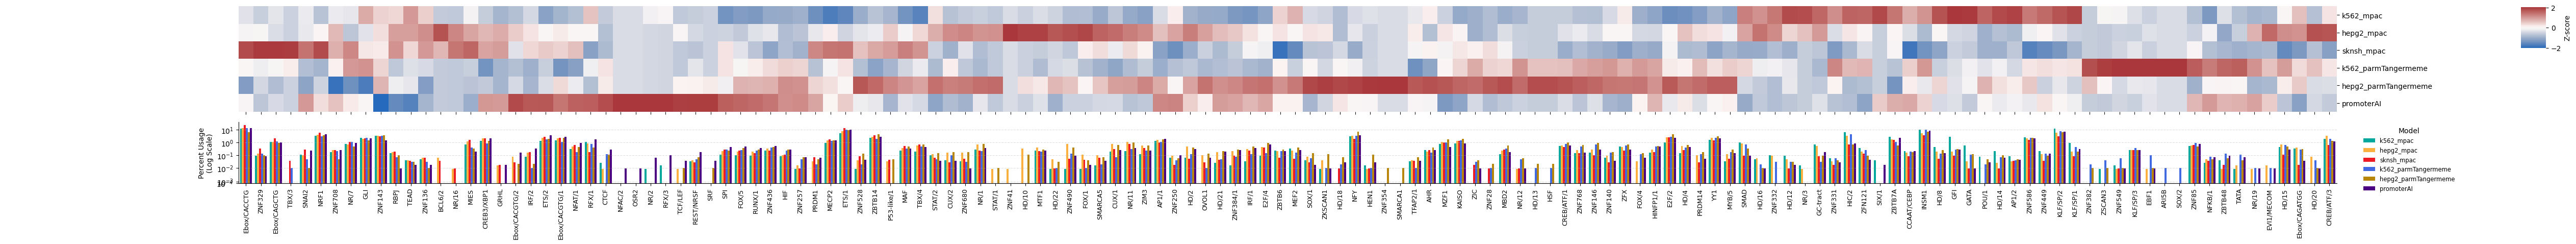

In [27]:
# plot all uncollapsed usage with parm tangermeme calls
reformat_tf_usage2plot_horizontal(all_uncollapsed,
                        [i for i in all_uncollapsed.keys() if 'percent_usage' in i and 'parmParm' not in i],
                        'horiz_uncollapsed_PARM_tangermeme_tf_usage.pdf',
                        barPalette)

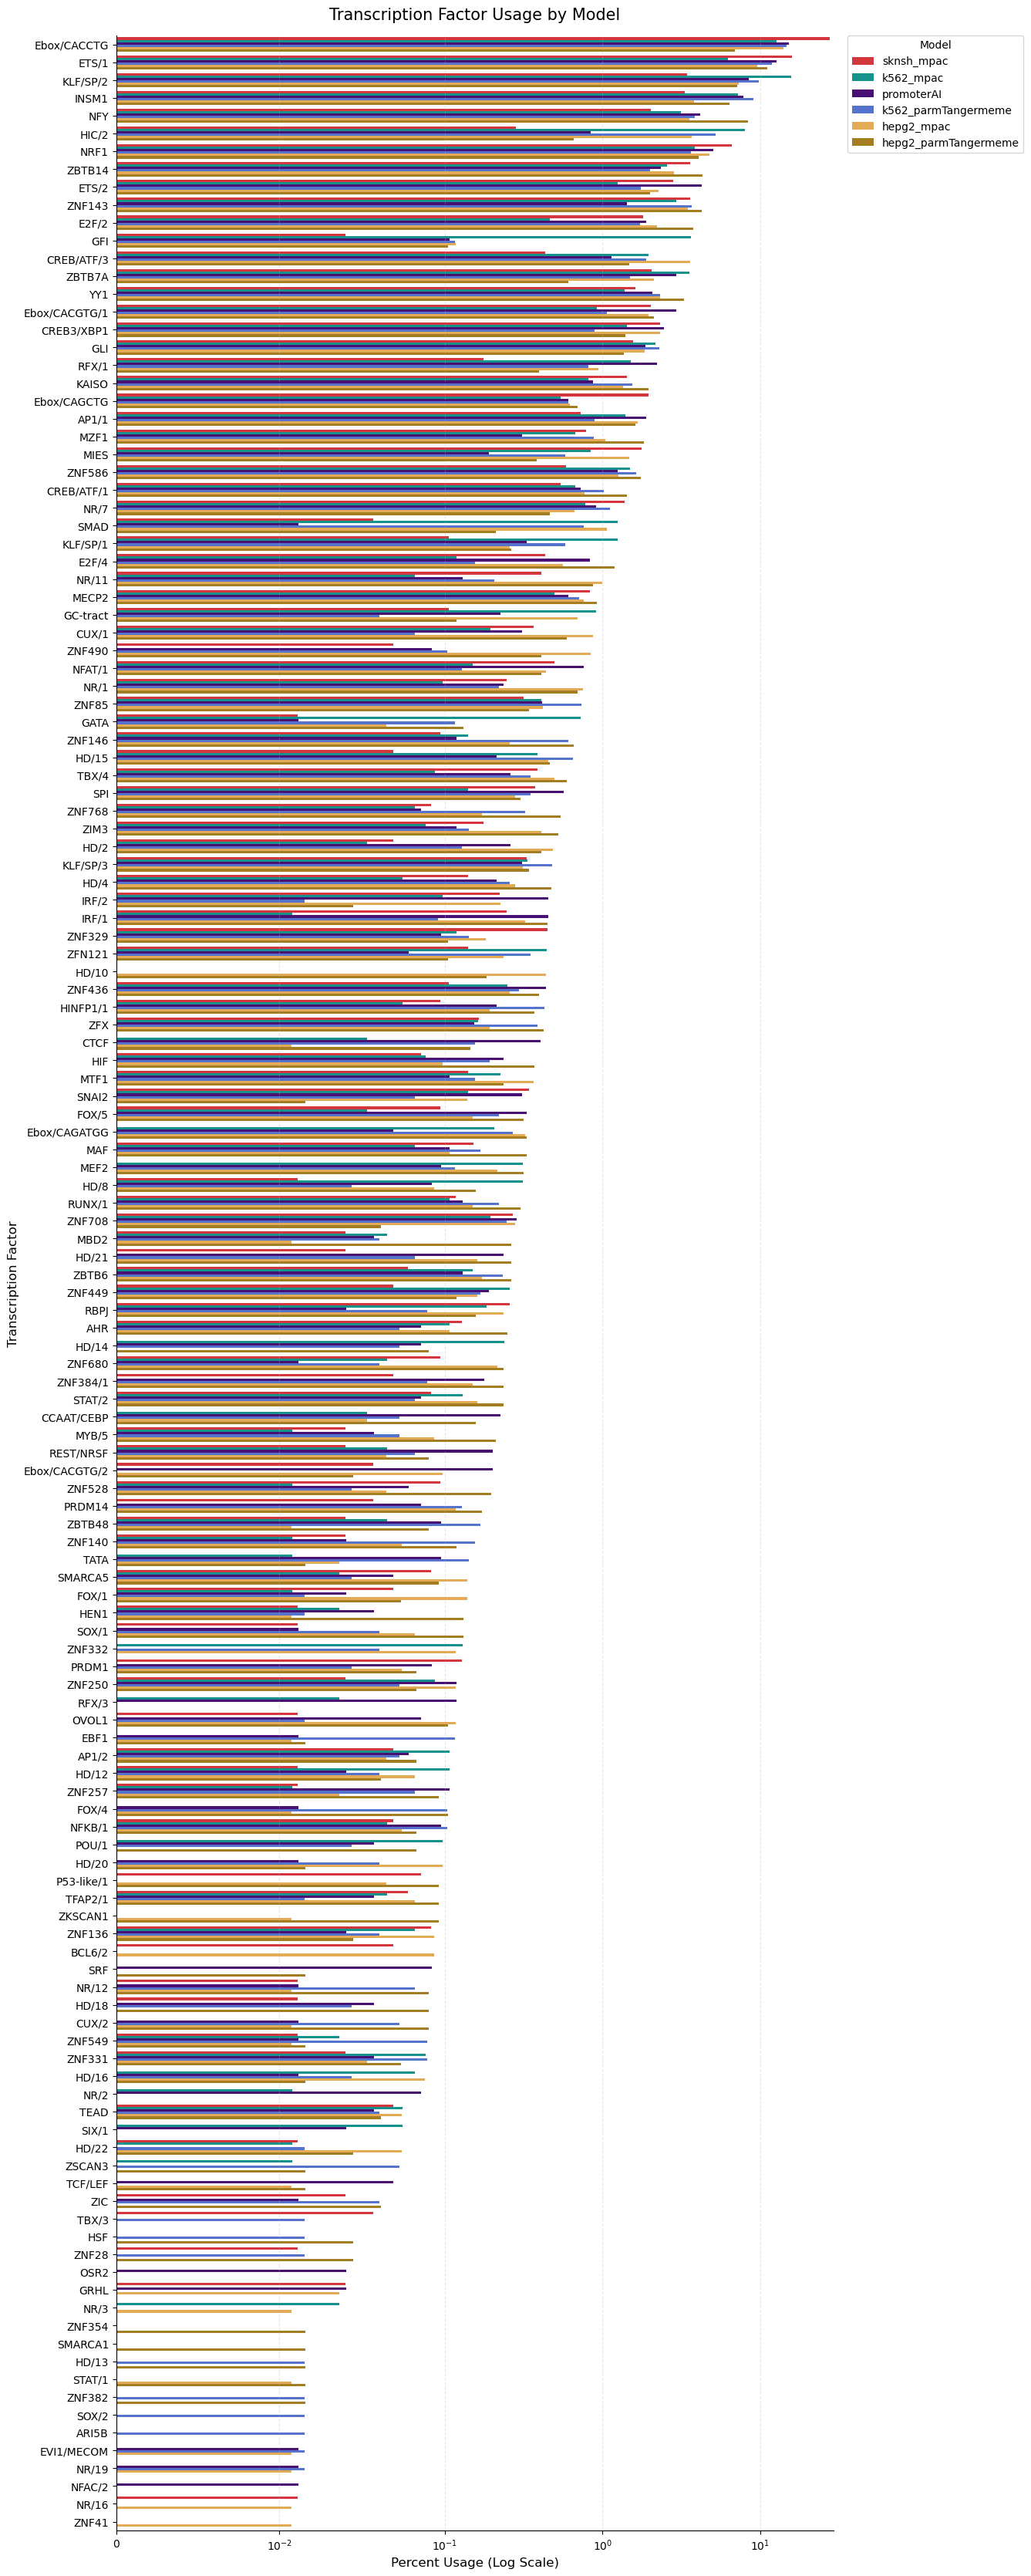

In [67]:
plot_tf_usage_horizontal_bars(all_collapsed, [i for i in all_collapsed.keys() if 'percent_usage' in i and 'parmParm' not in i], 'x', barPalette)

In [47]:
barPalette

{'k562_mpac': '#00A79D',
 'hepg2_mpac': '#FBB040',
 'sknsh_mpac': '#ED1C24',
 'k562_parmTangermeme': 'royalblue',
 'k562_parmParm': 'royalblue',
 'hepg2_parmTangermeme': 'darkgoldenrod',
 'hepg2_parmParm': 'darkgoldenrod',
 'promoterAI': 'indigo'}

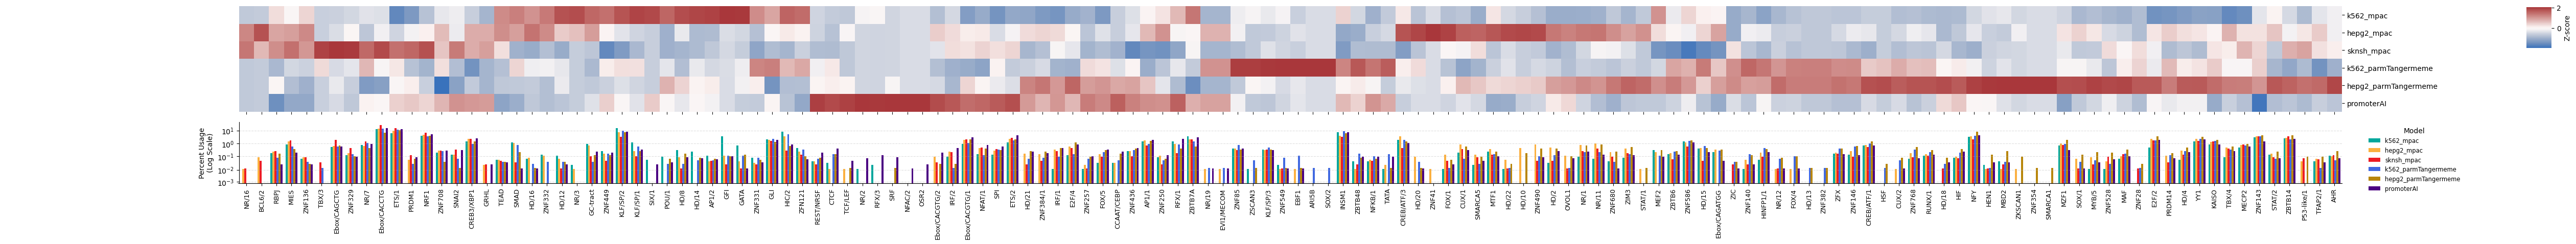

In [60]:
# plot all collapsed usage with parm tangermeme calls
reformat_tf_usage2plot_horizontal(all_collapsed,
                        [i for i in all_collapsed.keys() if 'percent_usage' in i and 'parmParm' not in i],
                        'horiz_collapsed_PARM_tangermeme_tf_usage.pdf',
                        barPalette)

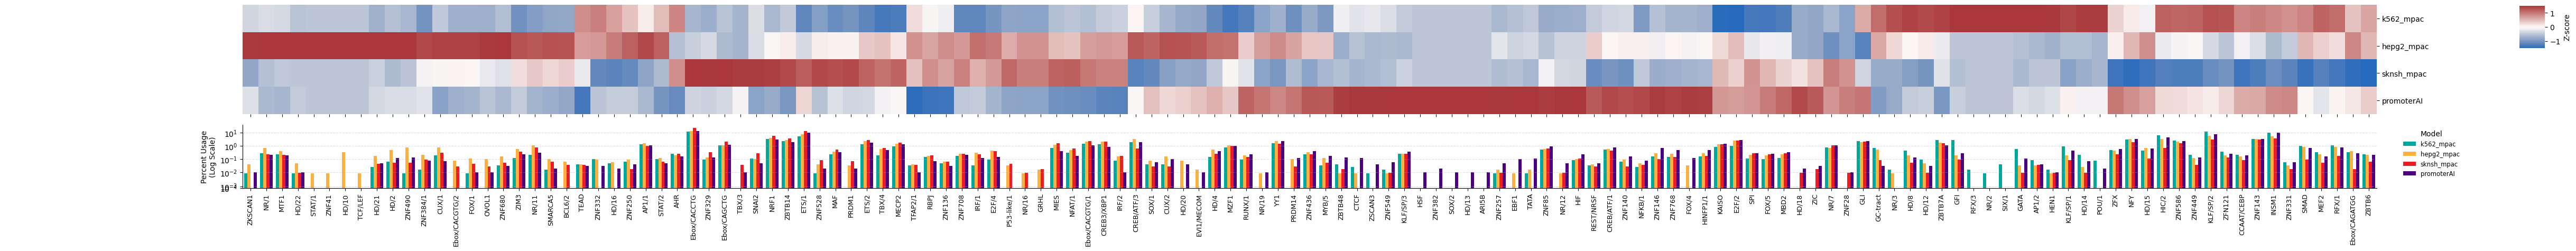

In [61]:
# plot all uncollapsed usage with parm tangermeme calls
reformat_tf_usage2plot_horizontal(all_uncollapsed,
                        [i for i in all_uncollapsed.keys() if 'percent_usage' in i and 'parmTangermeme' not in i],
                        'horiz_uncollapsed_PARM_parm_tf_usage.pdf',
                        barPalette)

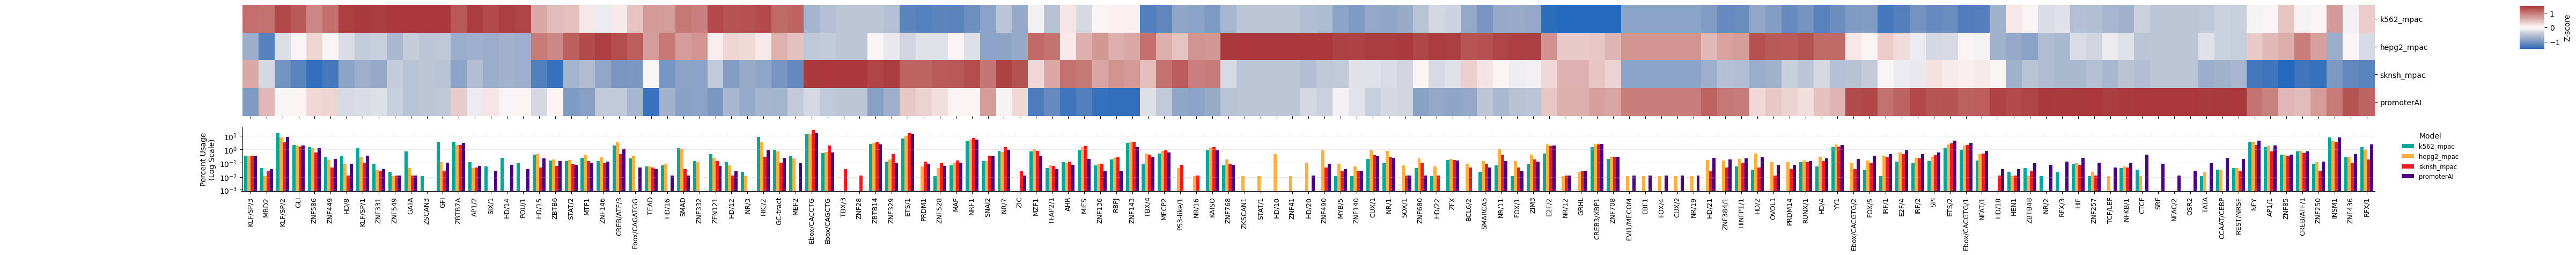

In [62]:
# plot all uncollapsed usage with parm tangermeme calls
reformat_tf_usage2plot_horizontal(all_collapsed,
                        [i for i in all_collapsed.keys() if 'percent_usage' in i and 'parmTangermeme' not in i],
                        'horiz_collapsed_PARM_parm_tf_usage.pdf',
                        barPalette)

In [127]:
# define a function for plotting the delta average skew
def plot_l2fc_usage (all_mean_phylo):
    # define filtering columns
    cols2filter = [i for i in all_mean_phylo.keys() if 'percent_usage' in i or i == 'tf_family' or i == 'mean_tf_usage']
    # define prediction columns
    predCols = [i for i in all_mean_phylo.keys() if 'percent_usage' in i]
    # filter to drop the attribution scores before reformatting
    data2plot = all_mean_phylo.filter(cols2filter)
    # 
    for col in predCols:
        # make the new column names
        newCol = f'{('_').join(col.split('_')[2:])}_l2fc'
        # calculate the delta mean
        data2plot.loc[:, newCol] = np.log2(data2plot[col] / data2plot['mean_tf_usage'])
    # filter for only delta_mean and tf_family
    deltaFilter = [i for i in data2plot.keys() if '_l2fc' in i or i == 'tf_family']
    delta2plot = data2plot.filter(deltaFilter)
    df2plot = delta2plot.set_index('tf_family')
    df2plot = df2plot.dropna(how='all')
    return df2plot


In [120]:
collapsed_l2fc2plot = plot_l2fc_usage(all_collapsed)

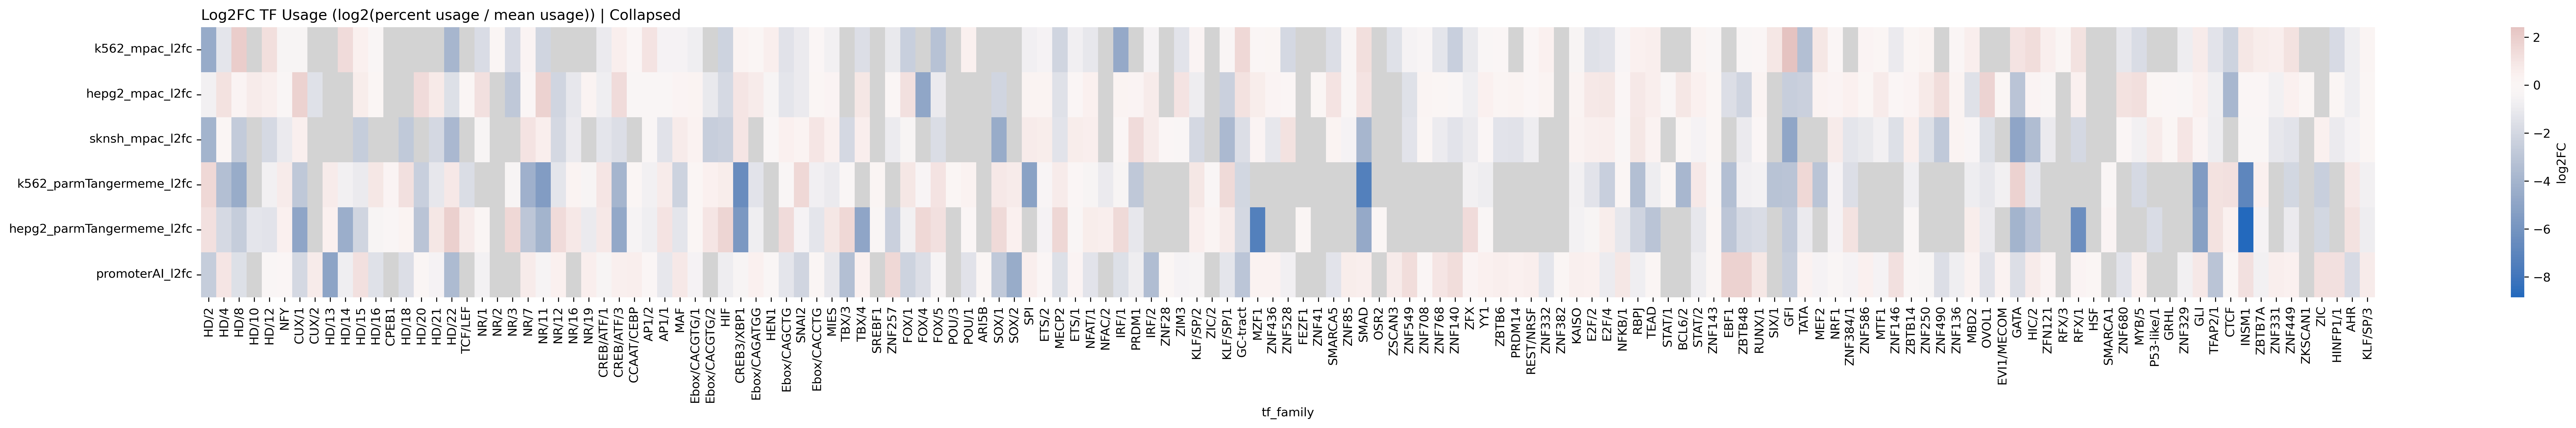

In [124]:
plt.figure(dpi=300, figsize = (40, 4))
ax = sns.heatmap(
    data = collapsed_l2fc2plot.T,
    cmap='vlag',
    center = 0,
    cbar_kws={'label': 'log2FC'}
)
ax.set_facecolor('lightgray')
plt.title('Log2FC TF Usage (log2(percent usage / mean usage)) | Collapsed', loc = 'left')
plt.savefig('collapsed_l2fc_tf_usage.pdf')

In [126]:
# define a function for plotting the delta average skew
def plot_delta_usage (all_mean_phylo):
    # define filtering columns
    cols2filter = [i for i in all_mean_phylo.keys() if 'percent_usage' in i or i == 'tf_family' or i == 'mean_tf_usage']
    # define prediction columns
    predCols = [i for i in all_mean_phylo.keys() if 'percent_usage' in i]
    # filter to drop the attribution scores before reformatting
    data2plot = all_mean_phylo.filter(cols2filter)
    # 
    for col in predCols:
        # make the new column names
        newCol = f'{('_').join(col.split('_')[2:])}_delta_mean'
        # calculate the delta mean
        data2plot.loc[:, newCol] = data2plot[col] - data2plot['mean_tf_usage']
    # filter for only delta_mean and tf_family
    deltaFilter = [i for i in data2plot.keys() if '_delta_mean' in i or i == 'tf_family']
    delta2plot = data2plot.filter(deltaFilter)
    df2plot = delta2plot.set_index('tf_family')
    df2plot = df2plot.dropna(how='all')
    return df2plot

In [128]:
collapsed_delta2plot = plot_delta_usage(all_collapsed)

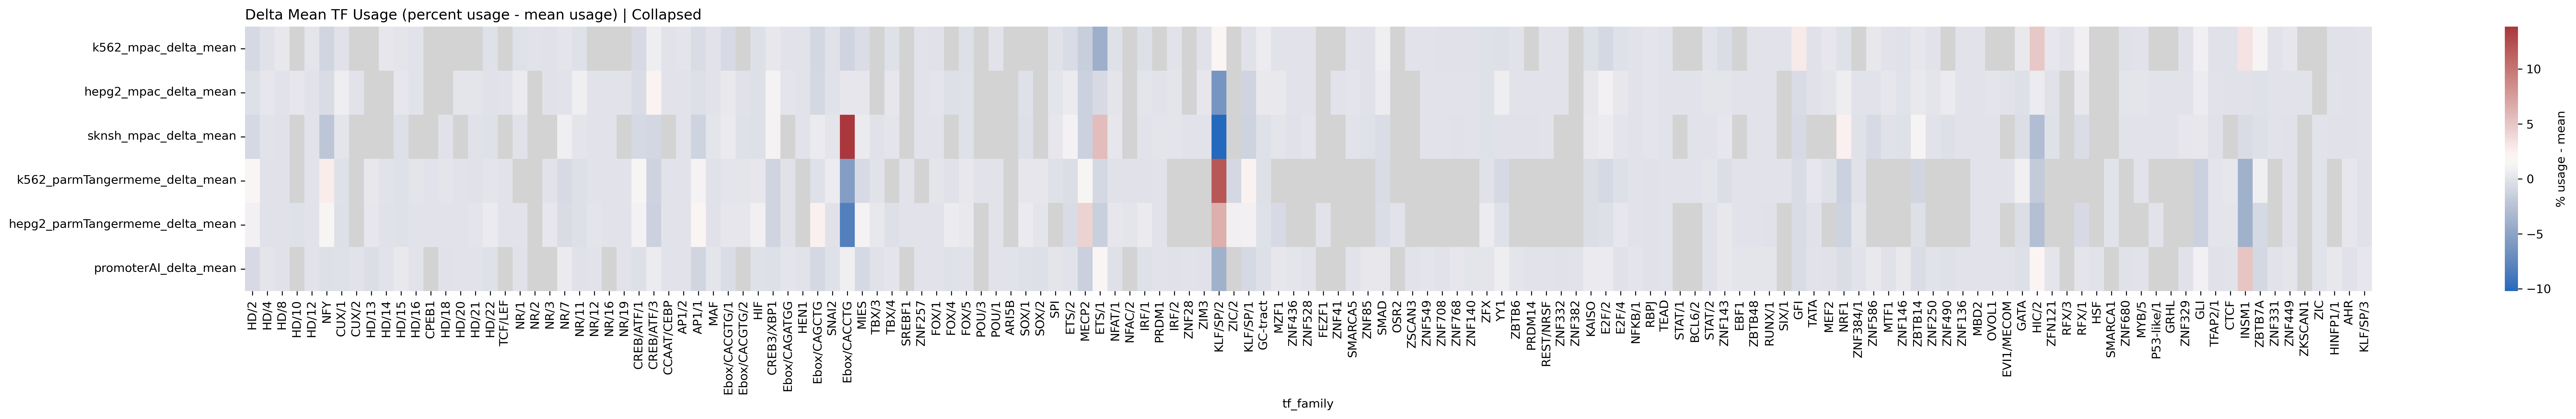

In [143]:
plt.figure(dpi=300, figsize = (40, 4))
ax = sns.heatmap(
    data = collapsed_delta2plot.T,
    cmap='vlag',
    #center = 0,
    cbar_kws={'label': '% usage - mean'}
)
ax.set_facecolor('lightgray')
plt.title('Delta Mean TF Usage (percent usage - mean usage) | Collapsed', loc = 'left')
plt.savefig('collapsed_deltaMean_tf_usage.pdf')

In [248]:
def plot_or_heatmap_with_sig_family(df_target, df_background, output_path, min_count=5):
    """
    Plots a Log2 Odds Ratio heatmap and overlays significance stars 
    based on FDR-corrected Fisher's Exact Test p-values.
    """
    
    # 1. Prepare Counts
    target_counts = df_target['tf_family'].value_counts()
    bg_counts = df_background['tf_family'].value_counts()
    
    total_target = len(df_target)
    total_bg = len(df_background)
    
    all_tfs = set(target_counts.index).union(set(bg_counts.index))
    
    results = []
    
    # 2. Calculate Stats (OR and P-value)
    for tf in all_tfs:
        a = target_counts.get(tf, 0)
        b = bg_counts.get(tf, 0)
        
        if (a + b) < min_count:
            continue
            
        c = total_target - a
        d = total_bg - b
        
        # Fisher's Exact Test
        odds_ratio, p_value = stats.fisher_exact([[a, b], [c, d]], alternative='two-sided')
        
        # Log2 Calculation (with pseudocount smoothing)
        # We smooth only for the PLOT (Log2), but use real counts for the STATS (Fisher)
        smooth_or = ( (a + 0.5) * (d + 0.5) ) / ( (b + 0.5) * (c + 0.5) )
        
        results.append({
            'TF': tf,
            'Log2OR': np.log2(smooth_or),
            'P_Value': p_value
        })
        
    df_res = pd.DataFrame(results).set_index('TF')
    
    # 3. Multiple Hypothesis Correction (FDR)
    reject, pvals_corrected, _, _ = multipletests(df_res['P_Value'], method='fdr_bh')
    df_res['FDR'] = pvals_corrected
    
    # 4. Generate Star Labels
    def get_stars(fdr):
        if fdr < 0.001: return '***'
        if fdr < 0.01:  return '**'
        if fdr < 0.05:  return '*'
        return ''
    
    df_res['Stars'] = df_res['FDR'].apply(get_stars)
    
    # 5. Sort by Enrichment
    df_res = df_res.sort_values('Log2OR', ascending=False)
    
    # 6. Prepare Matrices for Seaborn
    # Data Matrix (for colors)
    heatmap_data = df_res[['Log2OR']]
    # Label Matrix (for text) - Must match shape of Data Matrix
    annot_labels = df_res[['Stars']]
    
    # 7. Dynamic Height
    num_tfs = len(heatmap_data)
    calc_height = max(8, num_tfs * 0.2)
    
    print(f"Plotting {num_tfs} TFs with significance stars.")
    
    # 8. Plot
    plt.figure(figsize=(6, calc_height))
    
    # Determine color limits
    max_abs = max(abs(heatmap_data['Log2OR'].min()), abs(heatmap_data['Log2OR'].max()))
    
    sns.heatmap(heatmap_data,
                cmap="vlag",
                center=0,
                vmin=-max_abs,
                vmax=max_abs,
                annot=annot_labels, # <--- Pass the stars here
                fmt="",             # <--- Tells Seaborn the annotations are strings, not numbers
                yticklabels=True,
                cbar_kws={'label': 'Log2 Odds Ratio (Enrichment)'},
                linewidths=0.5,
                linecolor='gray')
    
    plt.title("TF Enrichment (Stars = FDR Significance)")
    plt.ylabel("Transcription Factor")
    plt.tight_layout()
    #plt.savefig(output_path, dpi=300)
    #plt.close()
    
    print(f"Heatmap saved to: {output_path}")
    return df_res

Plotting 107 TFs with significance stars.
Heatmap saved to: x


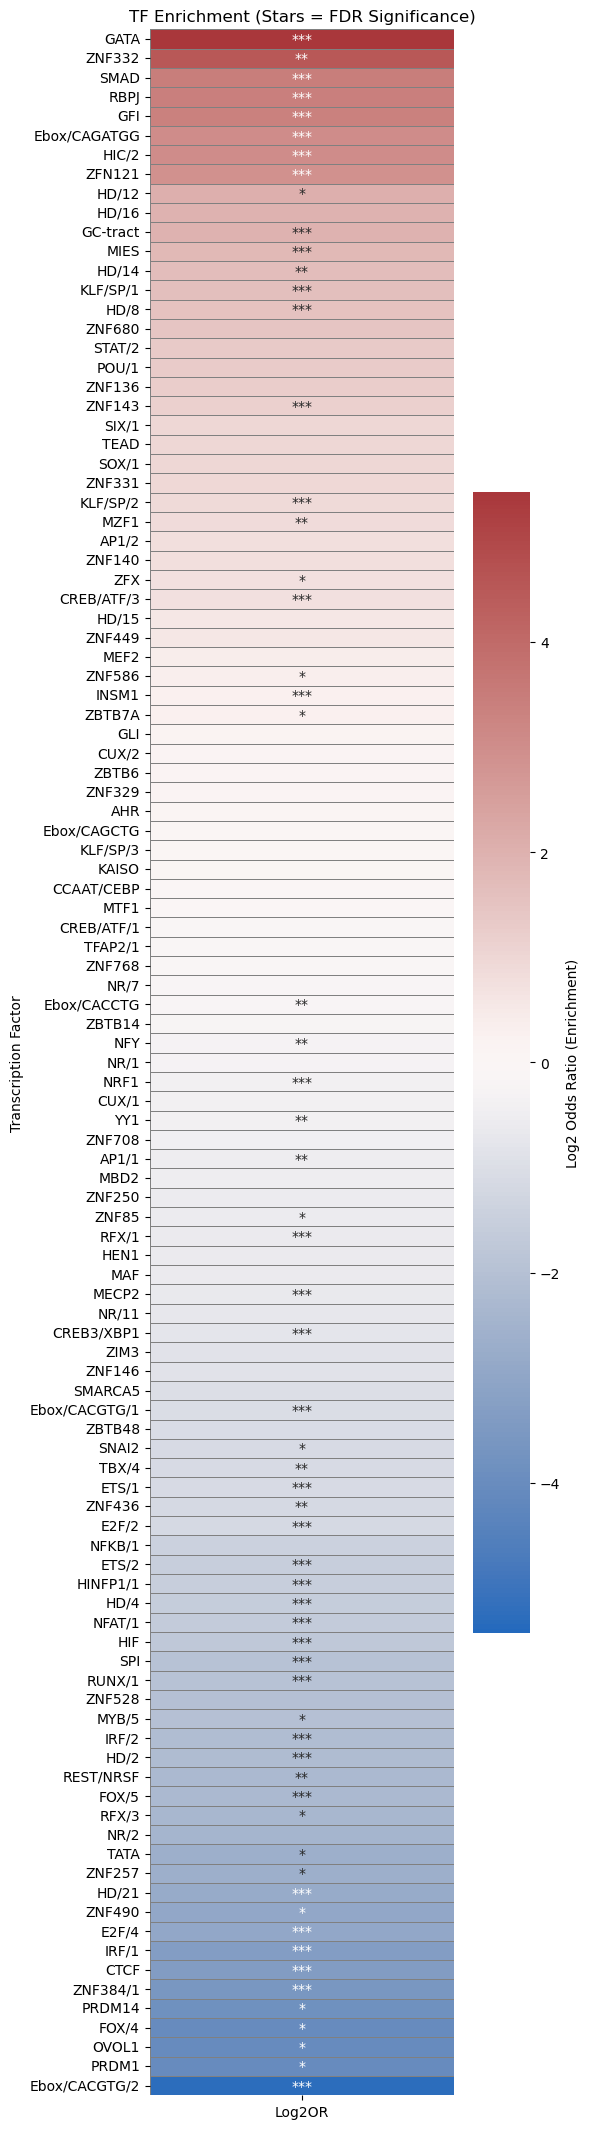

In [16]:
# plot uncollapsed MPAC vs. uncollapsed promoterAI
# k562
k_mpac_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(k_mpac_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 103 TFs with significance stars.
Heatmap saved to: x


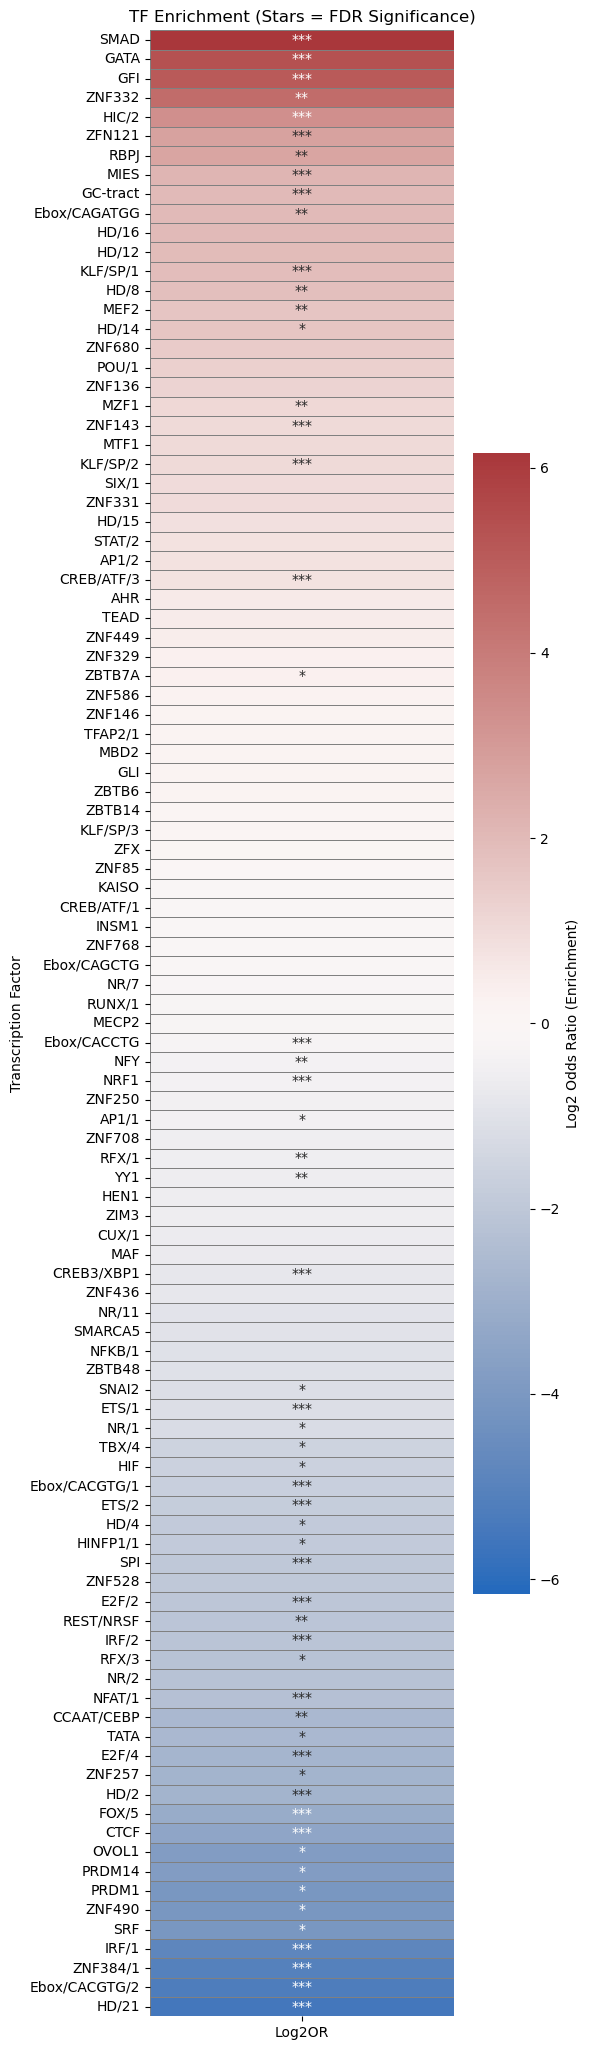

In [17]:
# plot uncollapsed MPAC vs. uncollapsed promoterAI
k_mpac_v_proAI_collapsed = plot_or_heatmap_with_sig_family(k_mpac_collapsed, promoterAI_collapsed, 'x')

Plotting 111 TFs with significance stars.
Heatmap saved to: x


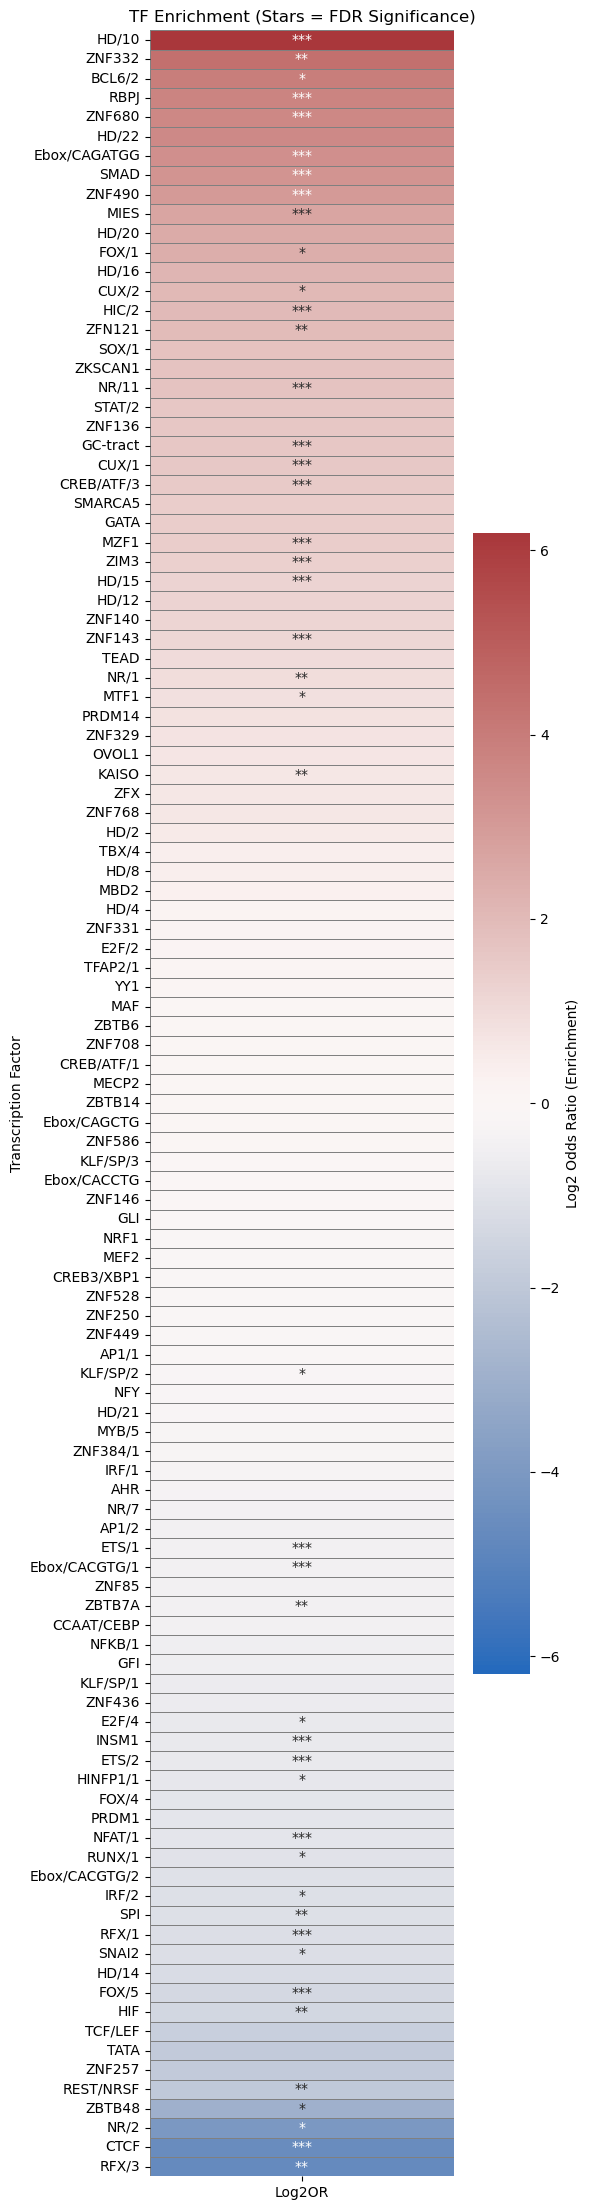

In [18]:
# plot uncollapsed MPAC vs. uncollapsed promoterAI
# hepg2
h_mpac_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(h_mpac_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 108 TFs with significance stars.
Heatmap saved to: x


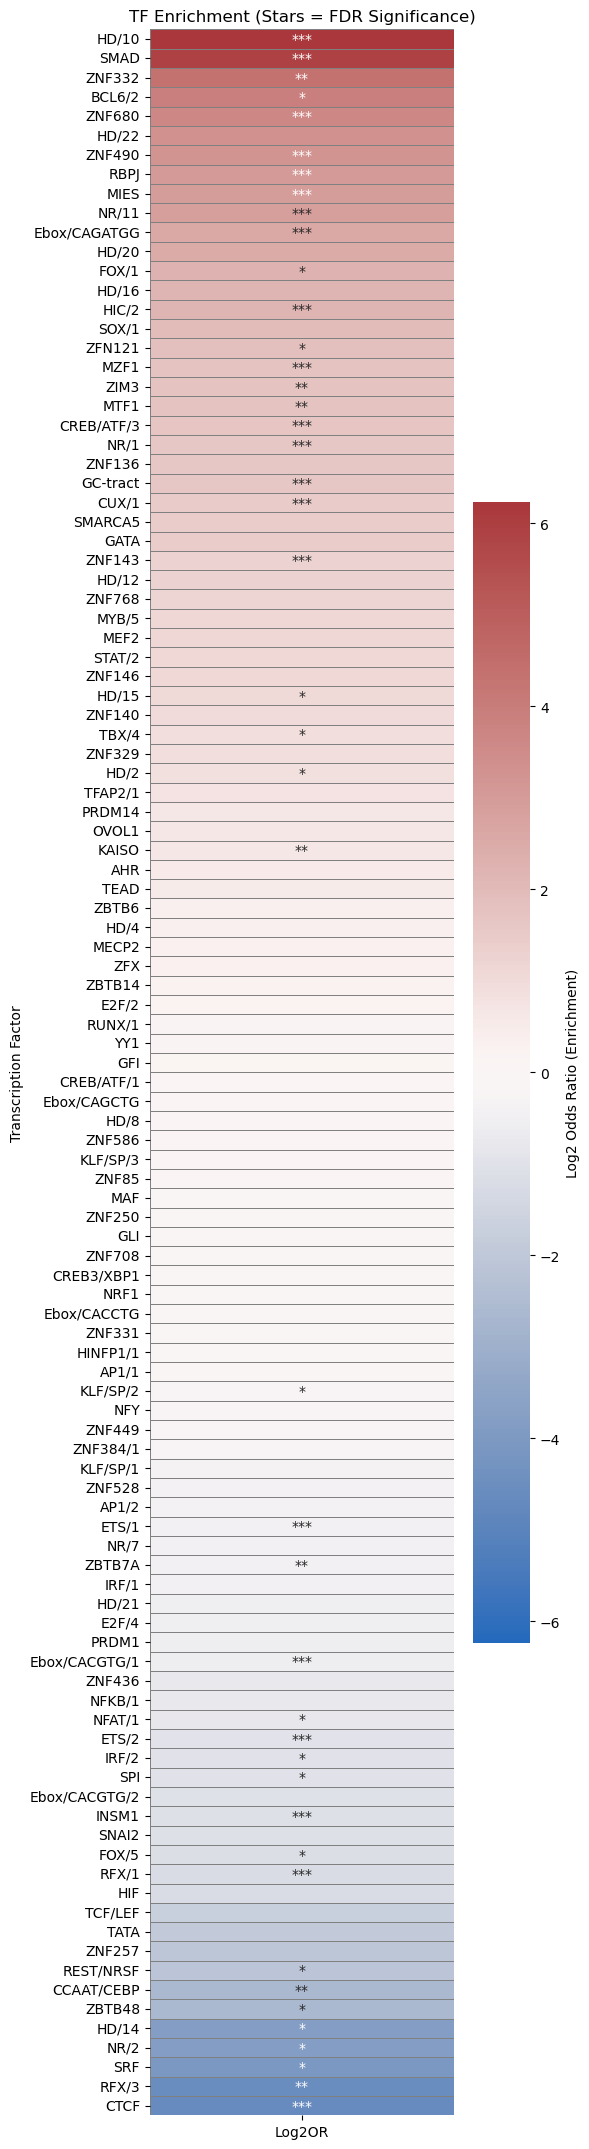

In [19]:
# plot collapsed MPAC vs. uncollapsed promoterAI
# hepg2
h_mpac_v_proAI_collapsed = plot_or_heatmap_with_sig_family(h_mpac_collapsed, promoterAI_collapsed, 'x')

Plotting 102 TFs with significance stars.
Heatmap saved to: x


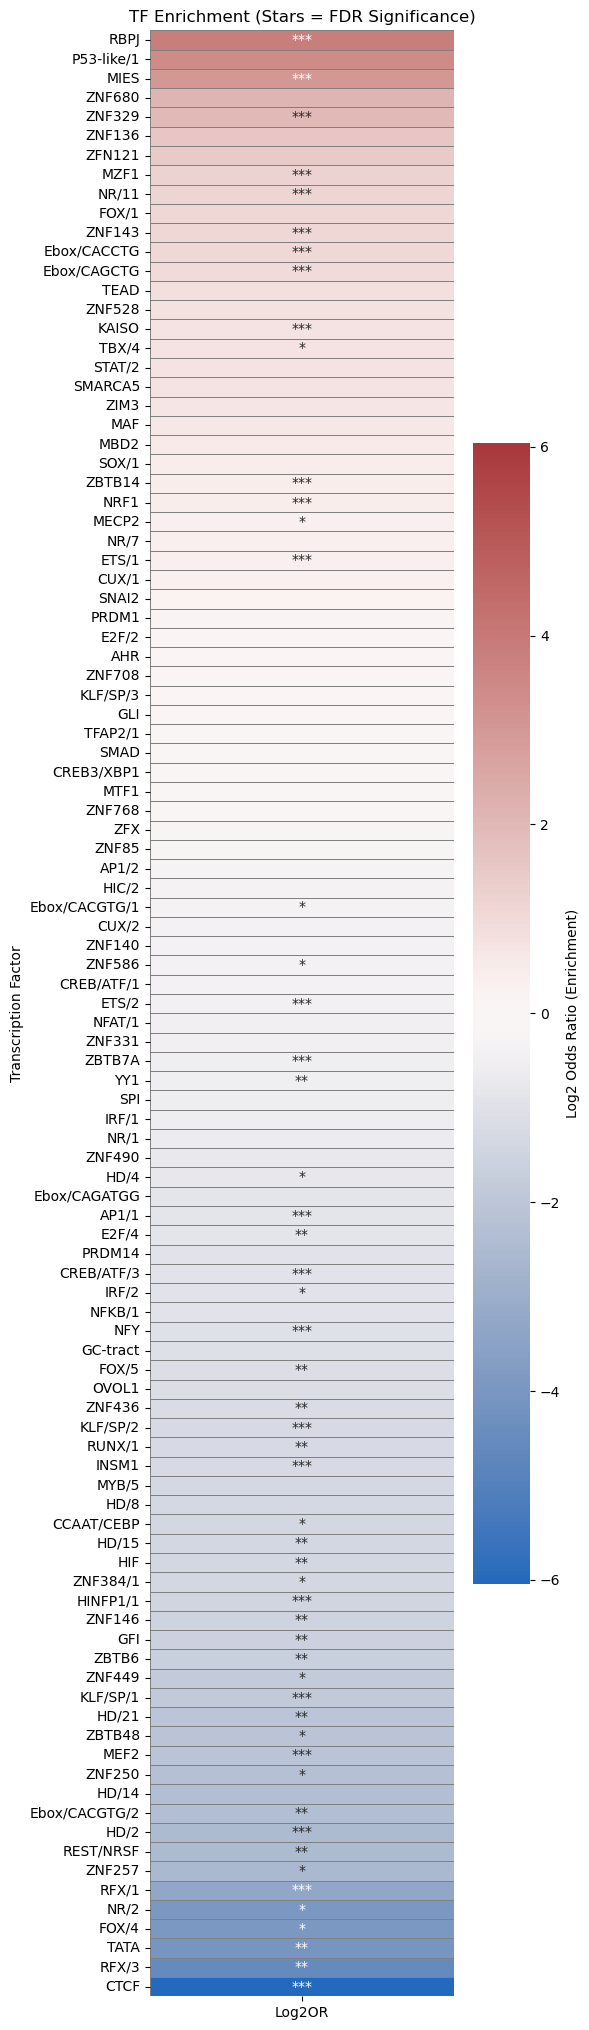

In [20]:
# plot uncollapsed MPAC vs. uncollapsed promoterAI
# sknsh
s_mpac_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(s_mpac_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 97 TFs with significance stars.
Heatmap saved to: x


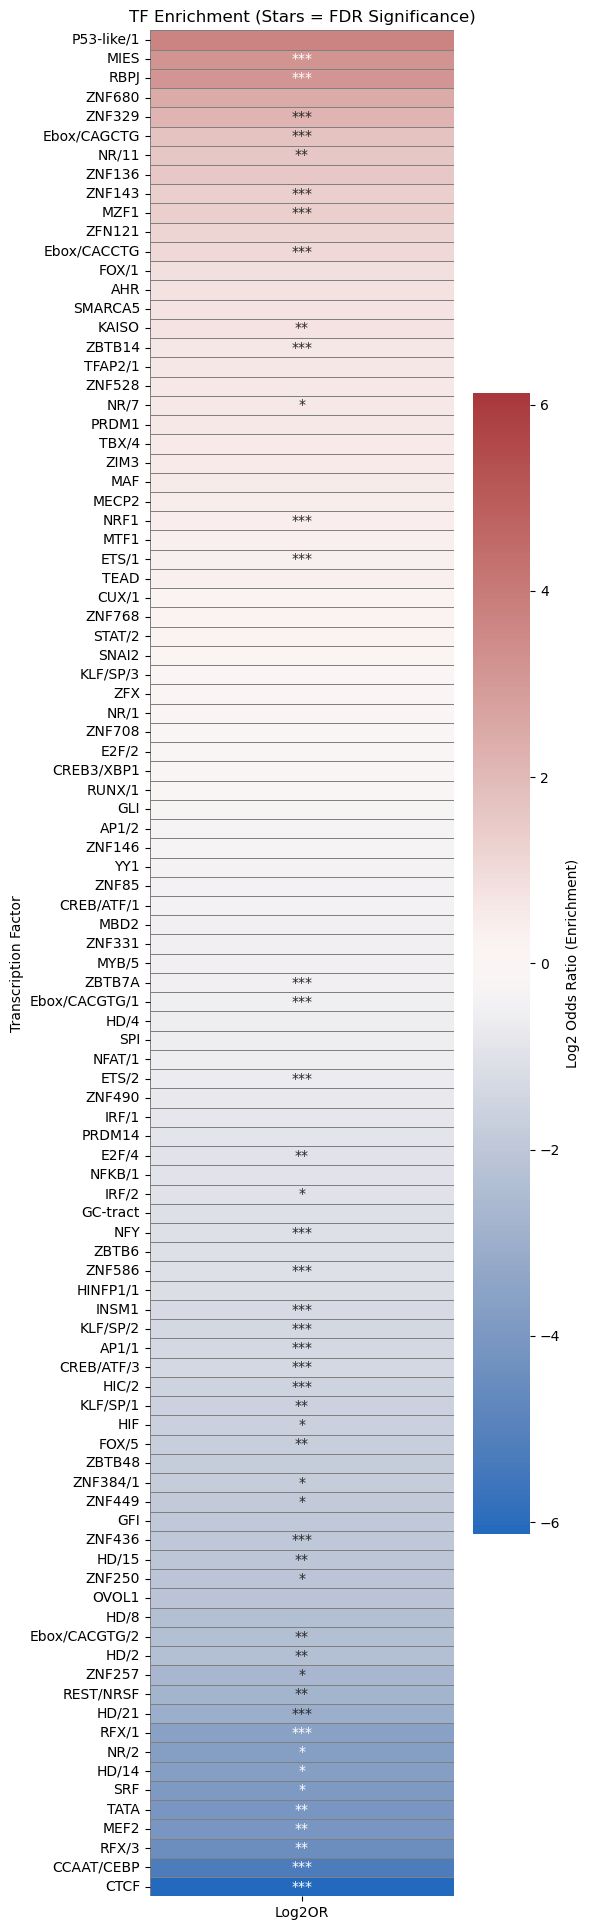

In [21]:
# plot collapsed MPAC vs. uncollapsed promoterAI
# sknsh
s_mpac_v_proAI_collapsed = plot_or_heatmap_with_sig_family(s_mpac_collapsed, promoterAI_collapsed, 'x')

Plotting 107 TFs with significance stars.
Heatmap saved to: x


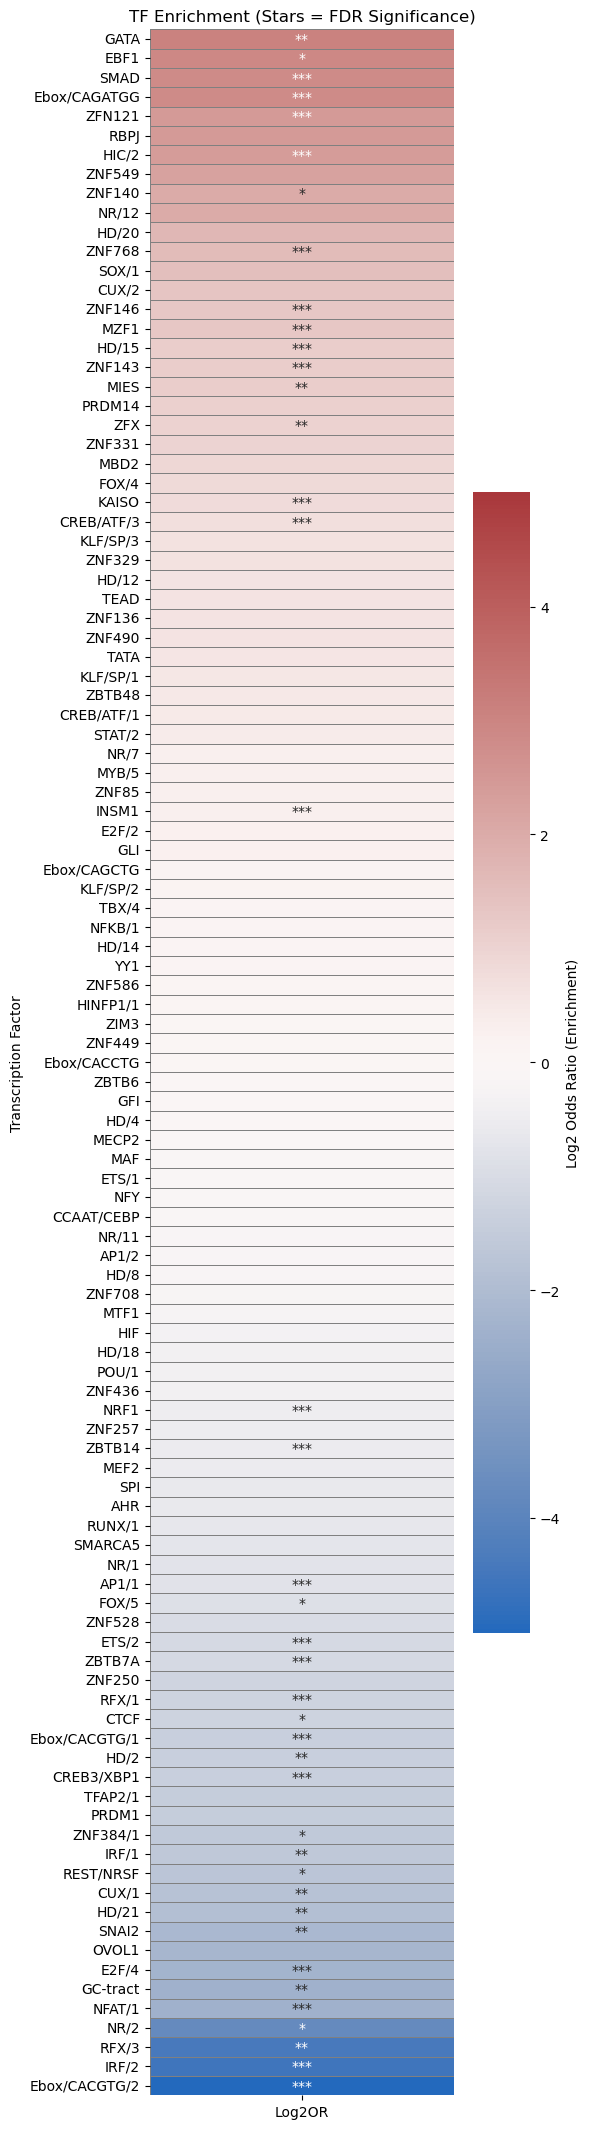

In [24]:
# plot uncollapsed PARM Tangermeme calls vs. uncollapsed promoterAI
# k562
k_parm_tangermeme_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(k_parmTangermeme_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 105 TFs with significance stars.
Heatmap saved to: x


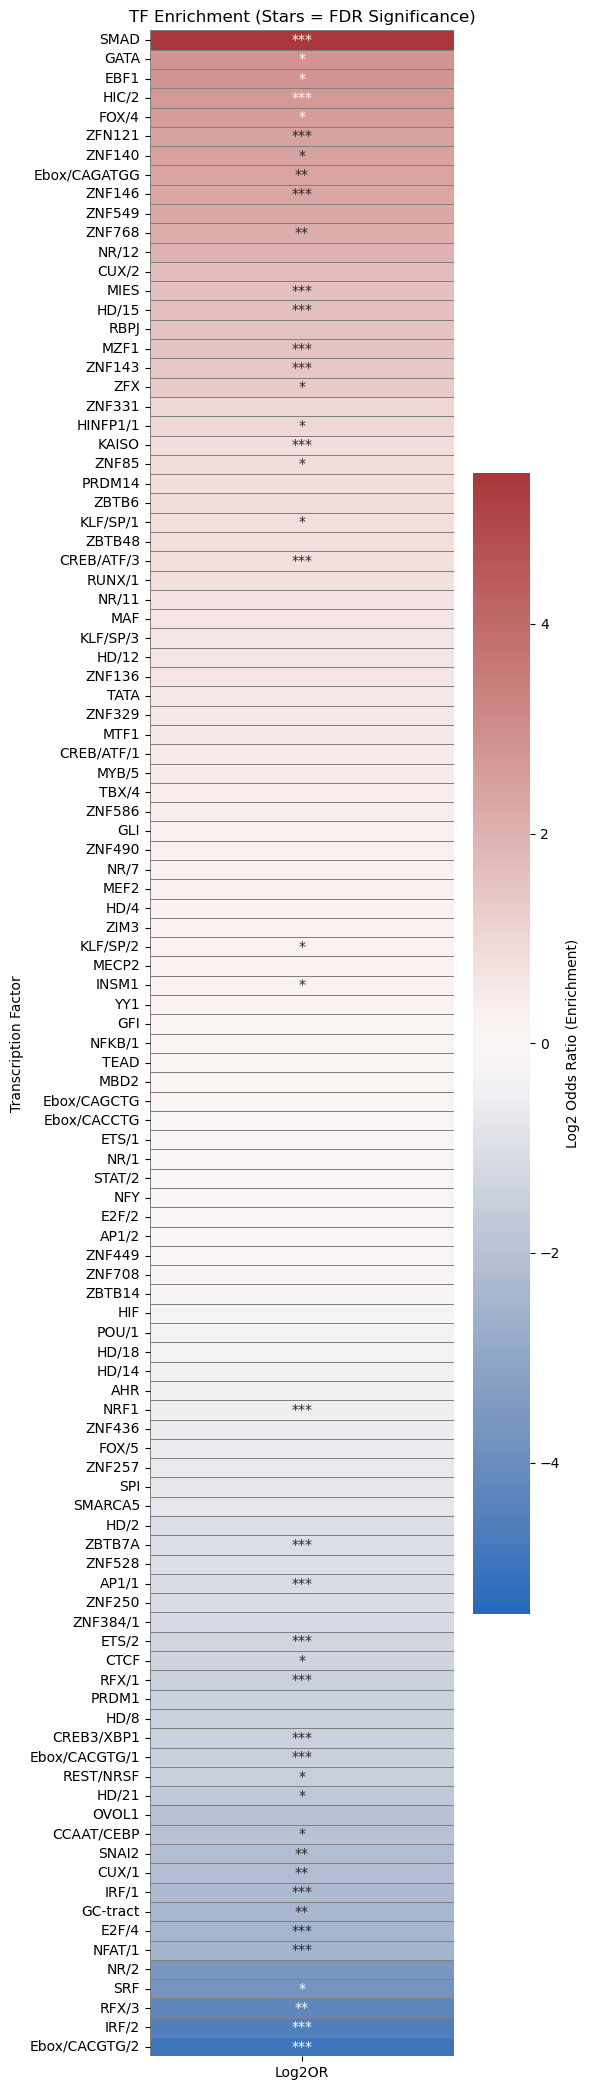

In [25]:
# plot collapsed PARM Tangermeme calls vs. uncollapsed promoterAI
# k562
k_parm_tangerememe_v_proAI_collapsed = plot_or_heatmap_with_sig_family(k_parmTangermeme_collapsed, promoterAI_collapsed, 'x')

Plotting 112 TFs with significance stars.
Heatmap saved to: x


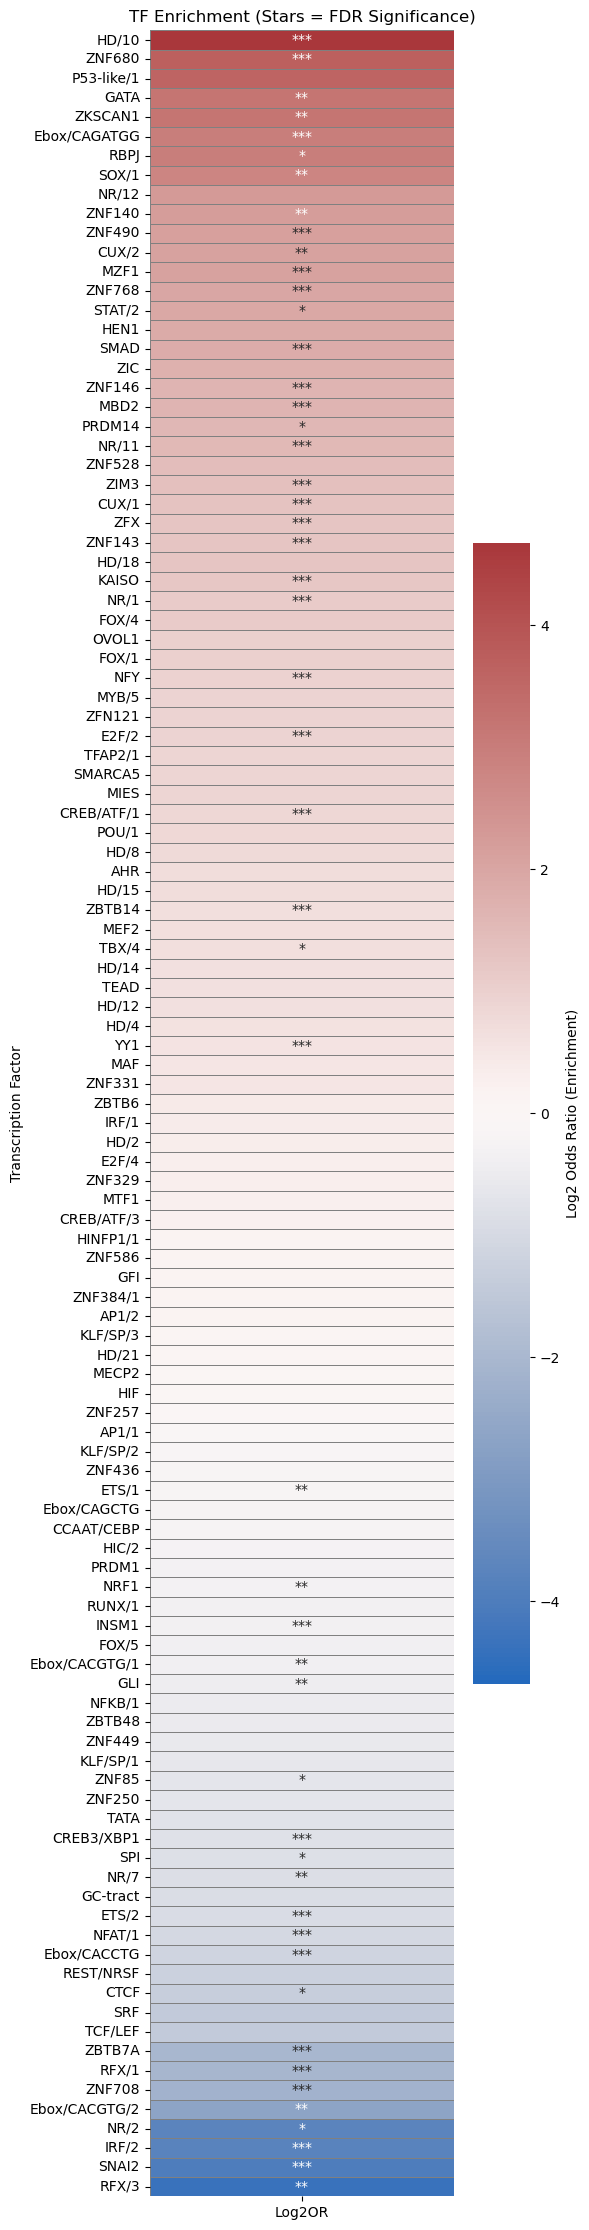

In [26]:
# plot uncollapsed PARM Tangermeme calls vs. uncollapsed promoterAI
# hepg2
h_parm_tangermeme_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(h_parmTangermeme_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 111 TFs with significance stars.
Heatmap saved to: x


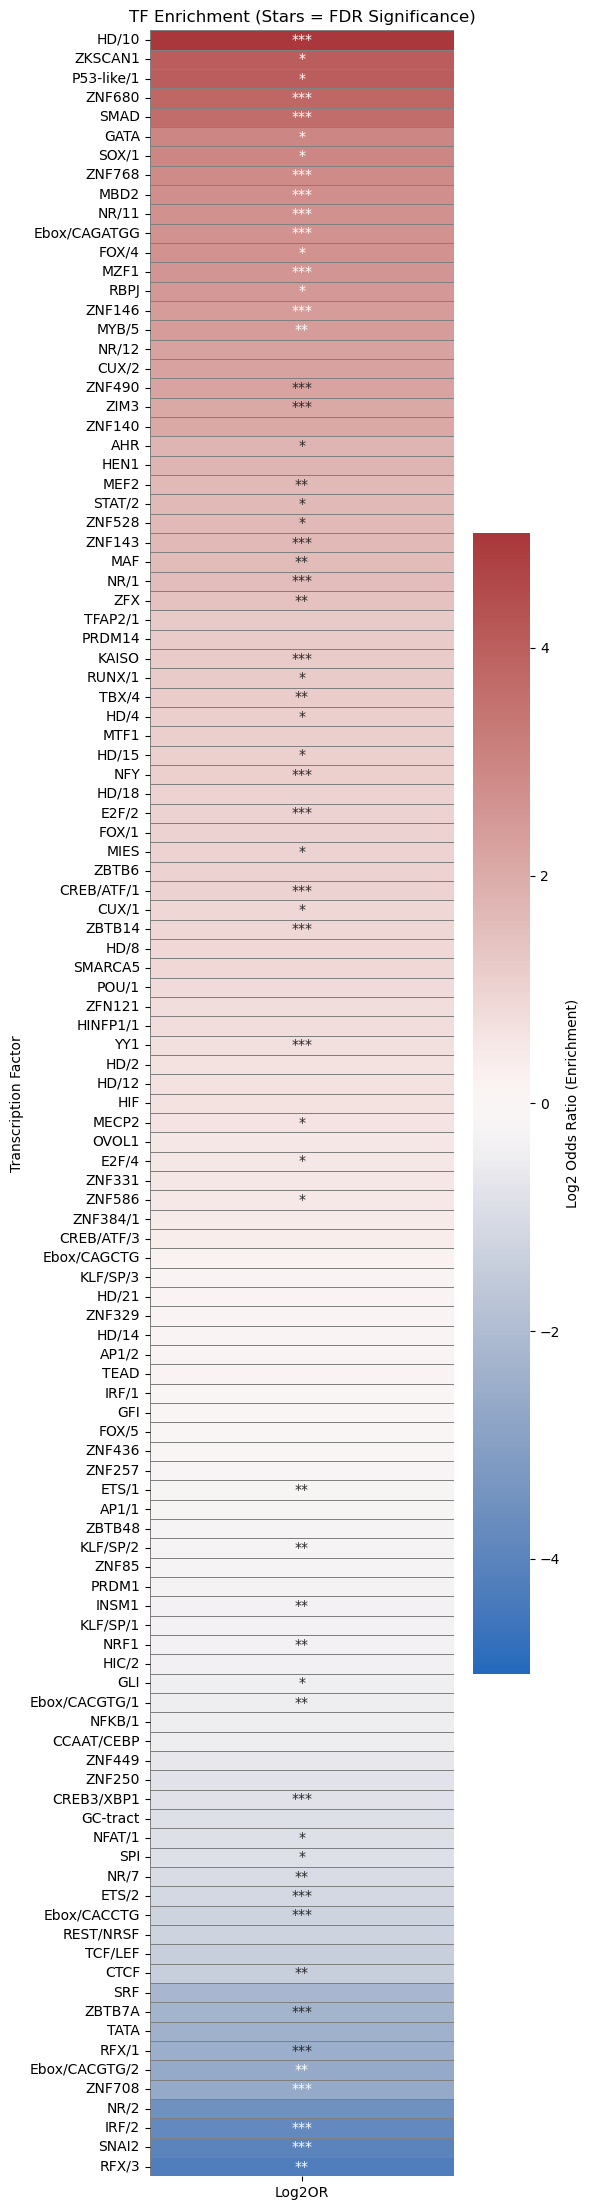

In [27]:
# plot collapsed PARM Tangermeme calls vs. collapsed promoterAI
# hepg2
h_parm_tangermeme_v_proAI_collapsed = plot_or_heatmap_with_sig_family(h_parmTangermeme_collapsed, promoterAI_collapsed, 'x')

Plotting 116 TFs with significance stars.
Heatmap saved to: x


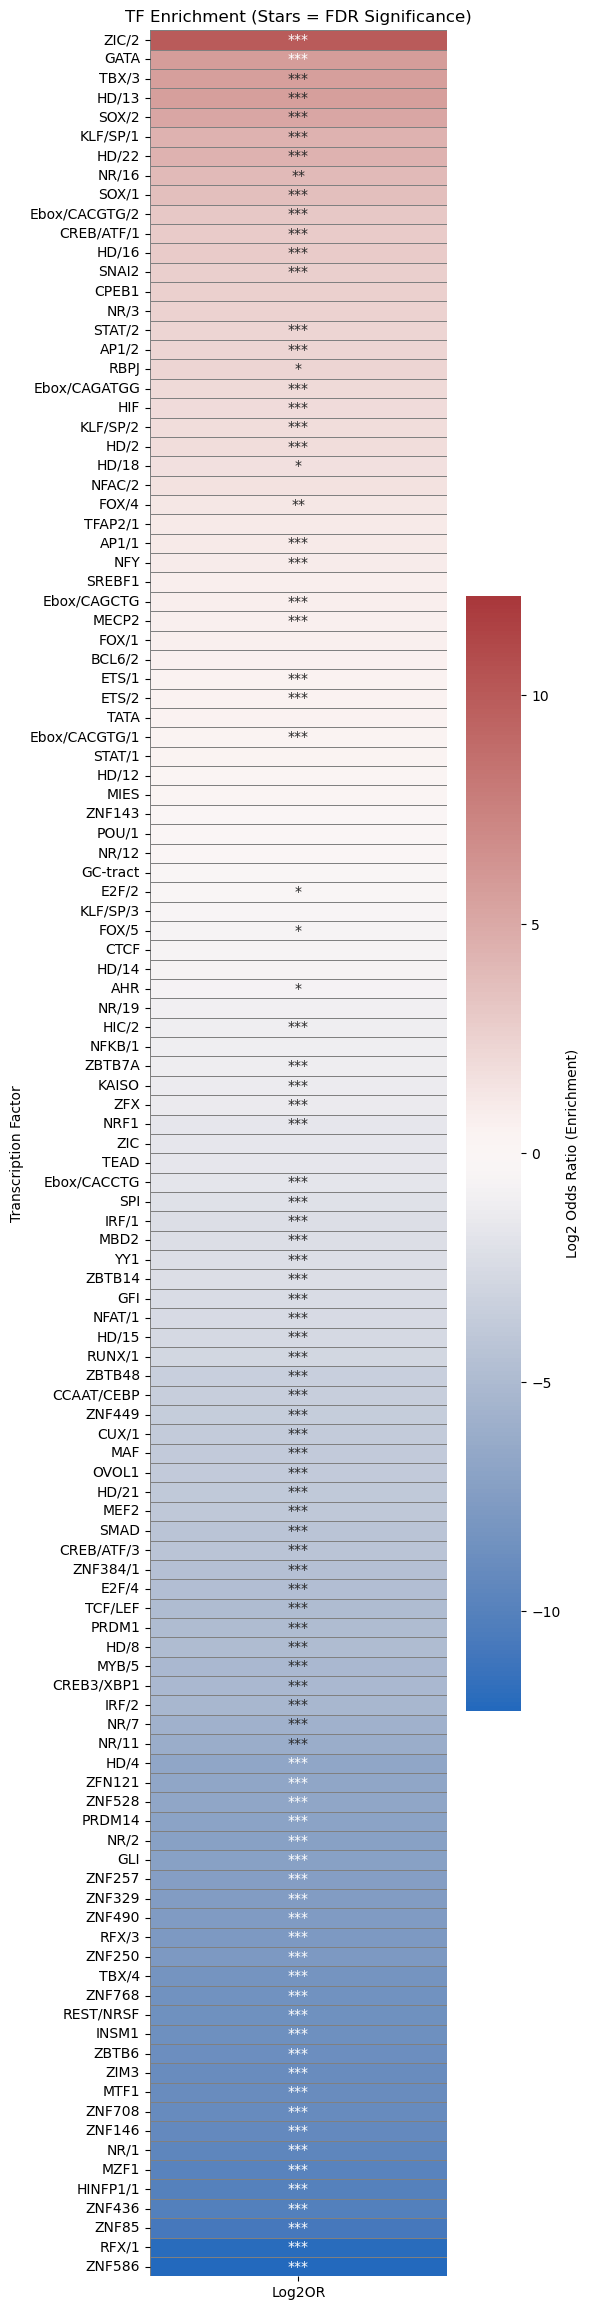

In [28]:
# plot uncollapsed PARM PARM calls vs. uncollapsed promoterAI
# k562
k_parm_parm_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(k_parmParm_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 112 TFs with significance stars.
Heatmap saved to: x


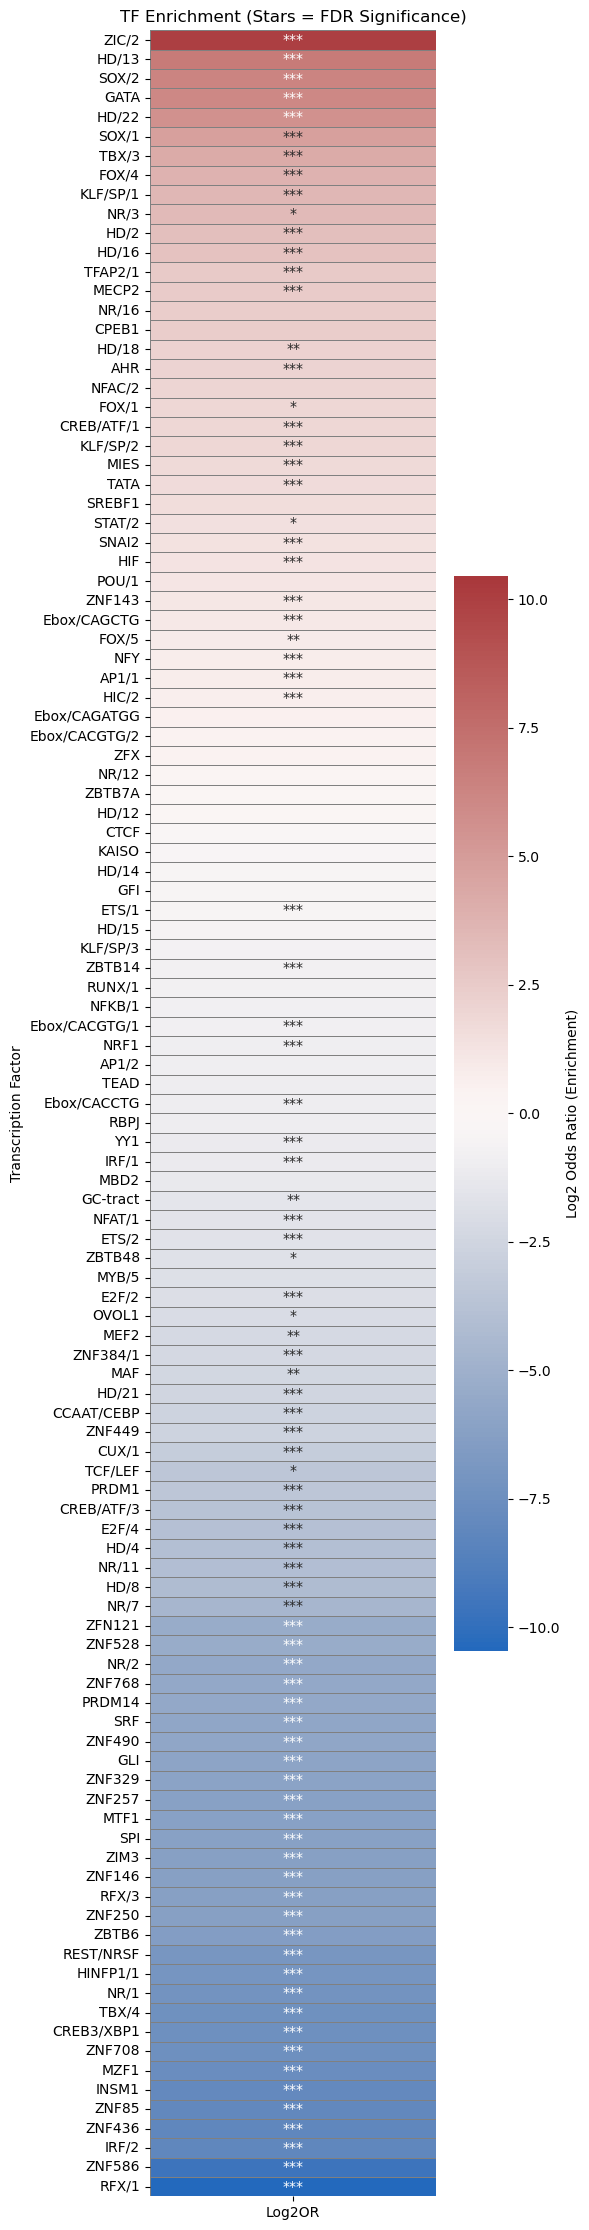

In [29]:
# plot collapsed PARM PARM calls vs. uncollapsed promoterAI
# k562
k_parm_parm_v_proAI_collapsed = plot_or_heatmap_with_sig_family(k_parmParm_collapsed, promoterAI_collapsed, 'x')

Plotting 113 TFs with significance stars.
Heatmap saved to: x


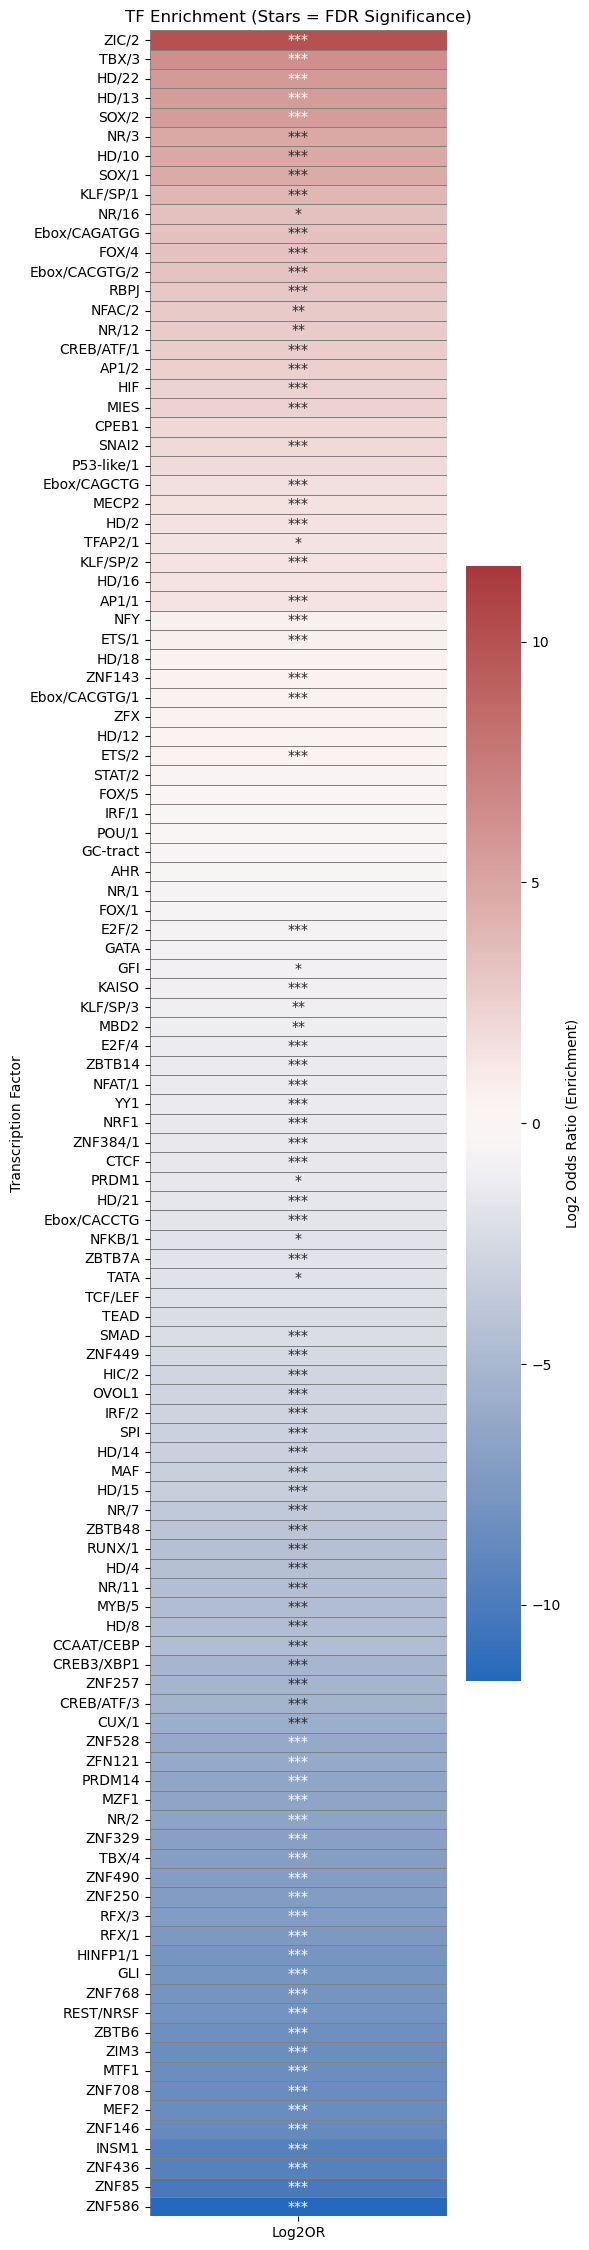

In [30]:
# plot uncollapsed PARM PARM calls vs. uncollapsed promoterAI
# hepg2
h_parm_parm_v_proAI_uncollapsed = plot_or_heatmap_with_sig_family(h_parmParm_uncollapsed, promoterAI_uncollapsed, 'x')

Plotting 111 TFs with significance stars.
Heatmap saved to: x


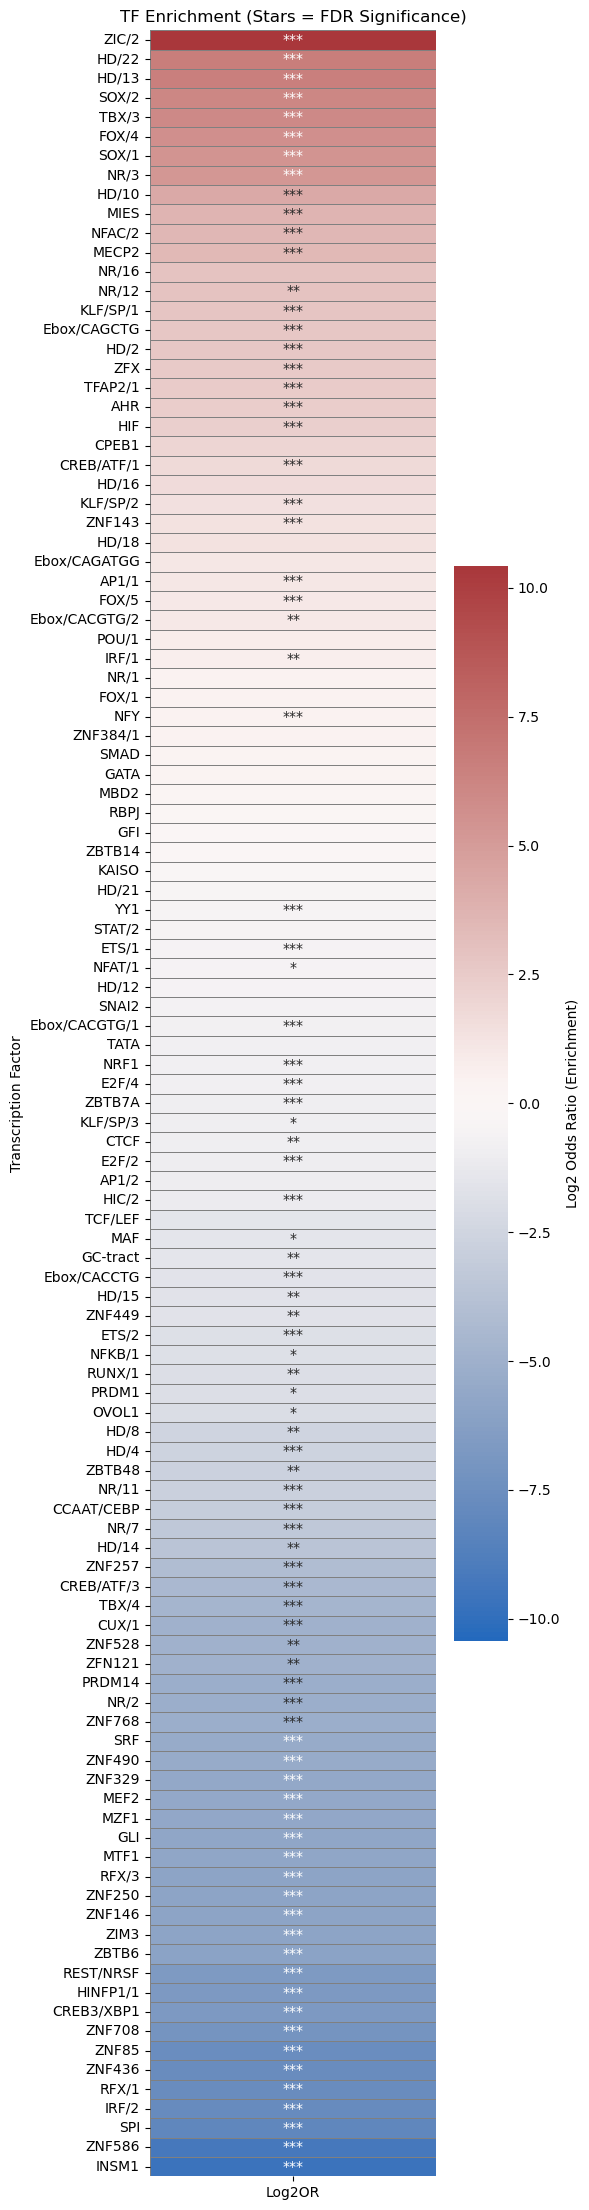

In [31]:
# plot collapsed PARM PARM calls vs. uncollapsed promoterAI
# hepg2
h_parm_parm_v_proAI_collapsed = plot_or_heatmap_with_sig_family(h_parmParm_collapsed, promoterAI_collapsed, 'x')